# HMDA Regression Dataset

This notebook works on the final regression sample.

The original HMDA dataset had about 14 million records.

We first cleaned the full dataset.

We removed columns with very high missing values.

We removed invalid rows.

We removed duplicate rows.

We also kept only the approved loan records for the regression task.

After these steps the cleaned dataset had about 8 million records.

From this cleaned dataset we created a random approved sample with 500000 records.

This sample is used for regression modeling.

The target variable is loan_amount_000s.

This column shows the loan amount in thousands of dollars.

# Current data columns

The current regression file has 29 columns.

These columns describe the lender.

They also describe the loan type.

They describe the applicant.

They describe the property location.

They also describe the census tract around the property.

The target column is loan_amount_000s.


# HMDA Regression Data Preparation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_PATH = Path("hmda_regression_approved_500k.csv")
df = pd.read_csv("hmda_regression_approved_500k.csv")


TARGET_COL = "loan_amount_000s"
CLASS_TARGET_COL = "loan_approved"

RANDOM_STATE = 42
PLOT_SAMPLE_SIZE = 10000

# Dataset structure

We first check the columns.

We also check the number of unique values.

This helps us find constant columns and high cardinality columns.

In [2]:
column_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [df[col].dtype for col in df.columns],
    "unique_count": [df[col].nunique(dropna=False) for col in df.columns],
    "sample_values": [
        " | ".join(df[col].drop_duplicates().head(5).astype(str).tolist())
        for col in df.columns
    ]
})

display(column_summary.sort_values("unique_count", ascending=False))

,column,dtype,unique_count,sample_values
13,census_tract_number,float64,18321,28.13 | 85.04 | 11.0 | 4602.02 | 107.04
25,tract_to_msamd_income,float64,14917,268.3099975585937 | 109.37999725341795 | 62.90...
23,minority_population,float64,9423,18.36000061035156 | 31.440000534057617 | 87.51...
22,population,int64,8641,4444 | 5901 | 6792 | 4277 | 5411
0,respondent_id,str,4278,0000035295 | 33-0941669 | 7505400005 | 0000761...
27,number_of_1_to_4_family_units,int64,4061,1457 | 2276 | 1786 | 1549 | 2036
26,number_of_owner_occupied_units,int64,3272,1359 | 1551 | 716 | 1147 | 1338
6,loan_amount_000s,int64,2245,603 | 341 | 215 | 968 | 115
20,applicant_income_000s,int64,2074,529 | 71 | 59 | 350 | 46
11,county_name,str,884,Greenville County | San Diego County | Kings C...


# Column groups

We split the columns into simple groups.

The target is loan_amount_000s.

Numeric columns show continuous or semi continuous values.

Categorical columns show groups and labels.

Sensitive columns are used only for audit later.

In [3]:
numeric_cols = [
    "loan_amount_000s",
    "applicant_income_000s",
    "population",
    "minority_population",
    "hud_median_family_income",
    "tract_to_msamd_income",
    "number_of_owner_occupied_units",
    "number_of_1_to_4_family_units"
]

numeric_cols = [col for col in numeric_cols if col in df.columns]

numeric_feature_cols = [
    col for col in numeric_cols
    if col != TARGET_COL
]

categorical_cols = [
    "agency_name",
    "loan_type_name",
    "property_type_name",
    "loan_purpose_name",
    "owner_occupancy_name",
    "preapproval_name",
    "state_name",
    "county_name",
    "msamd_name",
    "lien_status_name"
]

categorical_cols = [col for col in categorical_cols if col in df.columns]

sensitive_cols = [
    "applicant_ethnicity_name",
    "co_applicant_ethnicity_name",
    "applicant_race_name_1",
    "co_applicant_race_name_1",
    "applicant_sex_name",
    "co_applicant_sex_name",
    "minority_population"
]

sensitive_cols = [col for col in sensitive_cols if col in df.columns]

high_cardinality_cols = [
    "respondent_id",
    "county_name",
    "msamd_name",
    "census_tract_number"
]

high_cardinality_cols = [col for col in high_cardinality_cols if col in df.columns]

print("Numeric columns:")
print(numeric_cols)

print("\nNumeric feature columns:")
print(numeric_feature_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nSensitive columns:")
print(sensitive_cols)

print("\nHigh cardinality columns:")
print(high_cardinality_cols)

Numeric columns:
['loan_amount_000s', 'applicant_income_000s', 'population', 'minority_population', 'hud_median_family_income', 'tract_to_msamd_income', 'number_of_owner_occupied_units', 'number_of_1_to_4_family_units']

Numeric feature columns:
['applicant_income_000s', 'population', 'minority_population', 'hud_median_family_income', 'tract_to_msamd_income', 'number_of_owner_occupied_units', 'number_of_1_to_4_family_units']

Categorical columns:
['agency_name', 'loan_type_name', 'property_type_name', 'loan_purpose_name', 'owner_occupancy_name', 'preapproval_name', 'state_name', 'county_name', 'msamd_name', 'lien_status_name']

Sensitive columns:
['applicant_ethnicity_name', 'co_applicant_ethnicity_name', 'applicant_race_name_1', 'co_applicant_race_name_1', 'applicant_sex_name', 'co_applicant_sex_name', 'minority_population']

High cardinality columns:
['respondent_id', 'county_name', 'msamd_name', 'census_tract_number']


# Cleaning validation

Invalid rows and duplicate rows were removed before this notebook.

We must still verify this step.

We check real missing values.

We check zero values that act like missing values.

We check invalid numeric ranges.

We check exact duplicate rows.

In [4]:
real_missing_values = {
    "",
    "nan", "NaN", "NAN",
    "none", "None", "NONE",
    "null", "Null", "NULL",
    "na", "NA", "N/A", "n/a",
    ".", "-", "--"
}

real_missing_values_lower = {v.lower() for v in real_missing_values}

zero_should_not_exist_cols = [
    "loan_amount_000s",
    "applicant_income_000s",
    "population",
    "hud_median_family_income",
    "tract_to_msamd_income",
    "number_of_owner_occupied_units",
    "number_of_1_to_4_family_units"
]

zero_should_not_exist_cols = [
    col for col in zero_should_not_exist_cols
    if col in df.columns
]

bounded_cols = {
    "minority_population": (0, 100)
}

def is_real_missing(s):
    return s.astype(str).str.strip().str.lower().isin(real_missing_values_lower)

def is_zero_like(s):
    temp = s.astype(str).str.strip()
    zero_text_mask = temp.str.fullmatch(r"0+(\.0+)?", na=False)
    zero_numeric_mask = pd.to_numeric(temp, errors="coerce").eq(0)
    return zero_text_mask | zero_numeric_mask

validation_rows = []

for col in df.columns:
    s = df[col].astype(str).str.strip()
    missing_mask = is_real_missing(s)
    
    zero_as_missing_count = 0
    non_numeric_count = 0
    invalid_range_count = 0
    
    if col in numeric_cols:
        numeric_s = pd.to_numeric(s, errors="coerce")
        non_numeric_count = int((numeric_s.isna() & ~missing_mask).sum())
        
        if col in zero_should_not_exist_cols:
            zero_as_missing_count = int((is_zero_like(s) & ~missing_mask).sum())
            invalid_range_count = int((numeric_s.notna() & (numeric_s <= 0)).sum())
        
        elif col in bounded_cols:
            low, high = bounded_cols[col]
            invalid_range_count = int(
                (numeric_s.notna() & ((numeric_s < low) | (numeric_s > high))).sum()
            )
        
        else:
            invalid_range_count = int((numeric_s.notna() & (numeric_s < 0)).sum())
    
    validation_rows.append({
        "column": col,
        "real_missing_count": int(missing_mask.sum()),
        "zero_as_missing_count": zero_as_missing_count,
        "non_numeric_count": non_numeric_count,
        "invalid_range_count": invalid_range_count
    })

cleaning_validation = pd.DataFrame(validation_rows)

cleaning_validation["total_problem_count"] = (
    cleaning_validation["real_missing_count"]
    + cleaning_validation["zero_as_missing_count"]
    + cleaning_validation["non_numeric_count"]
    + cleaning_validation["invalid_range_count"]
)

display(
    cleaning_validation
    .sort_values("total_problem_count", ascending=False)
    .reset_index(drop=True)
)

exact_duplicate_count = df.duplicated().sum()

print("Exact duplicate rows:", exact_duplicate_count)
print("Total detected problems:", int(cleaning_validation["total_problem_count"].sum()))

,column,real_missing_count,zero_as_missing_count,non_numeric_count,invalid_range_count,total_problem_count
0,respondent_id,0,0,0,0,0
1,agency_name,0,0,0,0,0
2,loan_type_name,0,0,0,0,0
3,property_type_name,0,0,0,0,0
4,loan_purpose_name,0,0,0,0,0
5,owner_occupancy_name,0,0,0,0,0
6,loan_amount_000s,0,0,0,0,0
7,preapproval_name,0,0,0,0,0
8,msamd_name,0,0,0,0,0
9,state_name,0,0,0,0,0


Exact duplicate rows: 264
Total detected problems: 0


The previous check found exact duplicate rows.

These rows have the same values in all columns.

They do not add new information to the dataset.

We remove them before EDA and modeling.

This helps avoid repeated samples in train and test data.

In [5]:
# Remove exact duplicate rows

rows_before = len(df)
duplicate_count_before = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)
duplicate_count_after = df.duplicated().sum()

print("Rows before duplicate removal:", rows_before)
print("Duplicate rows before removal:", duplicate_count_before)
print("Rows after duplicate removal:", rows_after)
print("Duplicate rows after removal:", duplicate_count_after)
print("Rows removed:", rows_before - rows_after)
print("New dataset shape:", df.shape)

Rows before duplicate removal: 500000
Duplicate rows before removal: 264
Rows after duplicate removal: 499736
Duplicate rows after removal: 0
Rows removed: 264
New dataset shape: (499736, 29)


# Outlier review policy

We do not remove outliers in this section.

Some models need special outlier handling.

We will review extreme values now.

Later each model can choose its own strategy.

In [6]:
percentiles = [0, 0.001, 0.005, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.995, 0.999, 1]

numeric_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

outlier_review = numeric_df.quantile(percentiles).T
outlier_review.columns = [f"p_{p}" for p in percentiles]

outlier_review["mean"] = numeric_df.mean()
outlier_review["std"] = numeric_df.std()

display(outlier_review)

,p_0,p_0.001,p_0.005,p_0.01,p_0.05,p_0.25,p_0.5,p_0.75,p_0.95,p_0.99,p_0.995,p_0.999,p_1,mean,std
loan_amount_000s,1.00,2.000000,4.00,5.00,30.000000,123.000000,197.000000,305.000000,599.000000,1100.000000,1440.000000,2500.00000,99000.0,247.185150,302.912039
applicant_income_000s,1.00,9.000000,15.00,19.00,31.000000,55.000000,85.000000,132.000000,281.000000,604.000000,872.000000,1945.26500,98544.0,117.738400,279.972730
population,93.00,813.000000,1361.00,1590.00,2397.000000,3886.000000,5214.000000,6959.000000,12382.000000,22552.000000,28187.000000,53812.00000,53812.0,6059.687117,4151.602954
minority_population,0.00,0.600000,1.66,2.16,4.600000,13.460000,26.620001,47.919998,89.129997,99.510002,100.000000,100.00000,100.0,33.796488,25.651558
hud_median_family_income,18000.00,18800.000000,25900.00,25900.00,53000.000000,61900.000000,68800.000000,79300.000000,107600.000000,110800.000000,113100.000000,113100.00000,131500.0,71561.552300,15540.823268
tract_to_msamd_income,6.32,28.309999,38.18,43.57,60.869999,90.449997,112.970001,139.539993,197.850006,250.949997,284.220001,346.98999,468.0,118.930377,42.797868
number_of_owner_occupied_units,4.00,82.000000,182.00,245.00,477.000000,950.000000,1356.000000,1882.000000,3199.000000,6543.000000,7554.000000,13975.00000,19529.0,1581.619035,1207.955047
number_of_1_to_4_family_units,5.00,60.000000,215.00,361.00,756.000000,1317.000000,1821.000000,2478.000000,4229.000000,7355.000000,10125.000000,15386.00000,25391.0,2098.165782,1471.844889


# Target analysis

The target is loan_amount_000s.

The value is measured in thousands of dollars.

We check the raw target and the log target.

The log target can reduce skew.

In [7]:
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df["log1p_loan_amount_for_eda"] = np.log1p(df[TARGET_COL])

target_summary = df[TARGET_COL].describe(
    percentiles=[0.001, 0.005, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.995, 0.999]
)

display(target_summary)

count    499736.000000
mean        247.185150
std         302.912039
min           1.000000
0.1%          2.000000
0.5%          4.000000
1%            5.000000
5%           30.000000
25%         123.000000
50%         197.000000
75%         305.000000
95%         599.000000
99%        1100.000000
99.5%      1440.000000
99.9%      2500.000000
max       99000.000000
Name: loan_amount_000s, dtype: float64

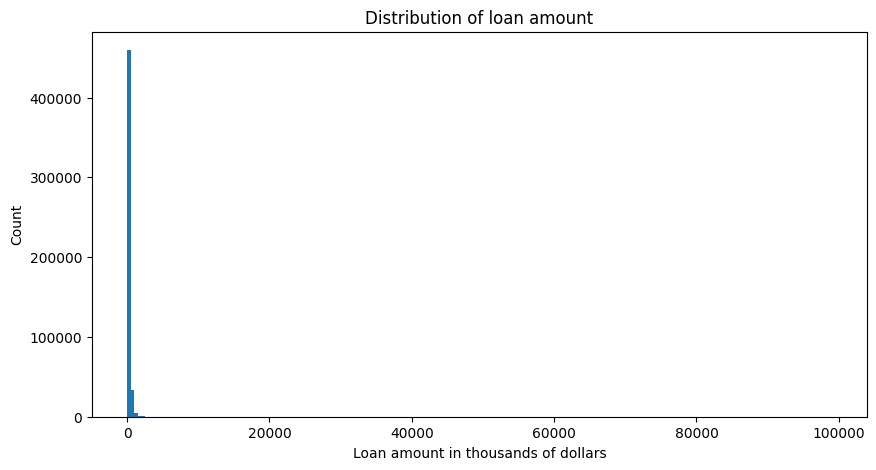

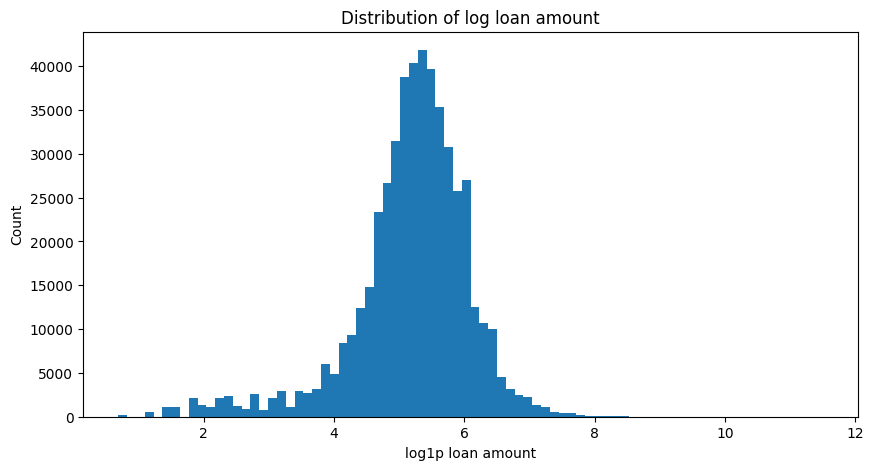

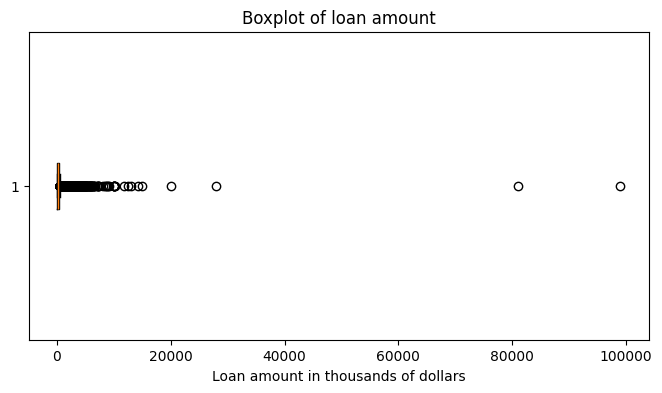

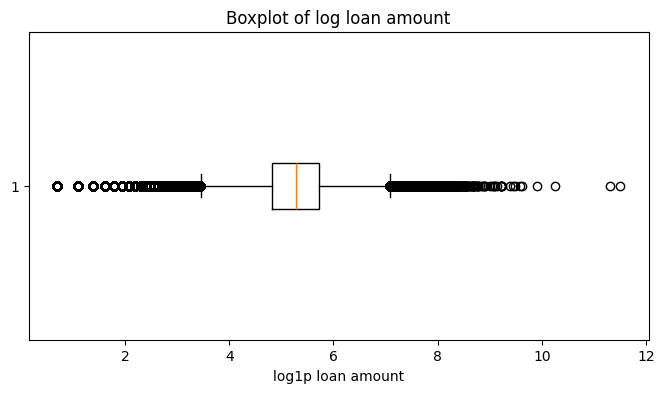

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(df[TARGET_COL].dropna(), bins=200)
plt.title("Distribution of loan amount")
plt.xlabel("Loan amount in thousands of dollars")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["log1p_loan_amount_for_eda"].dropna(), bins=80)
plt.title("Distribution of log loan amount")
plt.xlabel("log1p loan amount")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot(df[TARGET_COL].dropna(), vert=False)
plt.title("Boxplot of loan amount")
plt.xlabel("Loan amount in thousands of dollars")
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot(df["log1p_loan_amount_for_eda"].dropna(), vert=False)
plt.title("Boxplot of log loan amount")
plt.xlabel("log1p loan amount")
plt.show()

# Numeric feature analysis

We now study the numeric features.

We check their summary values.


In [9]:
numeric_feature_df = df[numeric_feature_cols].apply(pd.to_numeric, errors="coerce")

numeric_summary = numeric_feature_df.describe(
    percentiles=[0.001, 0.005, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.995, 0.999]
).T

numeric_summary["missing_count"] = numeric_feature_df.isna().sum()
numeric_summary["zero_count"] = (numeric_feature_df == 0).sum()

display(numeric_summary)

,count,mean,std,min,0.1%,0.5%,1%,5%,25%,50%,75%,95%,99%,99.5%,99.9%,max,missing_count,zero_count
applicant_income_000s,499736.0,117.738400,279.972730,1.00,9.000000,15.00,19.00,31.000000,55.000000,85.000000,132.000000,281.000000,604.000000,872.000000,1945.26500,98544.0,0,0
population,499736.0,6059.687117,4151.602954,93.00,813.000000,1361.00,1590.00,2397.000000,3886.000000,5214.000000,6959.000000,12382.000000,22552.000000,28187.000000,53812.00000,53812.0,0,0
minority_population,499736.0,33.796488,25.651558,0.00,0.600000,1.66,2.16,4.600000,13.460000,26.620001,47.919998,89.129997,99.510002,100.000000,100.00000,100.0,0,184
hud_median_family_income,499736.0,71561.552300,15540.823268,18000.00,18800.000000,25900.00,25900.00,53000.000000,61900.000000,68800.000000,79300.000000,107600.000000,110800.000000,113100.000000,113100.00000,131500.0,0,0
tract_to_msamd_income,499736.0,118.930377,42.797868,6.32,28.309999,38.18,43.57,60.869999,90.449997,112.970001,139.539993,197.850006,250.949997,284.220001,346.98999,468.0,0,0
number_of_owner_occupied_units,499736.0,1581.619035,1207.955047,4.00,82.000000,182.00,245.00,477.000000,950.000000,1356.000000,1882.000000,3199.000000,6543.000000,7554.000000,13975.00000,19529.0,0,0
number_of_1_to_4_family_units,499736.0,2098.165782,1471.844889,5.00,60.000000,215.00,361.00,756.000000,1317.000000,1821.000000,2478.000000,4229.000000,7355.000000,10125.000000,15386.00000,25391.0,0,0


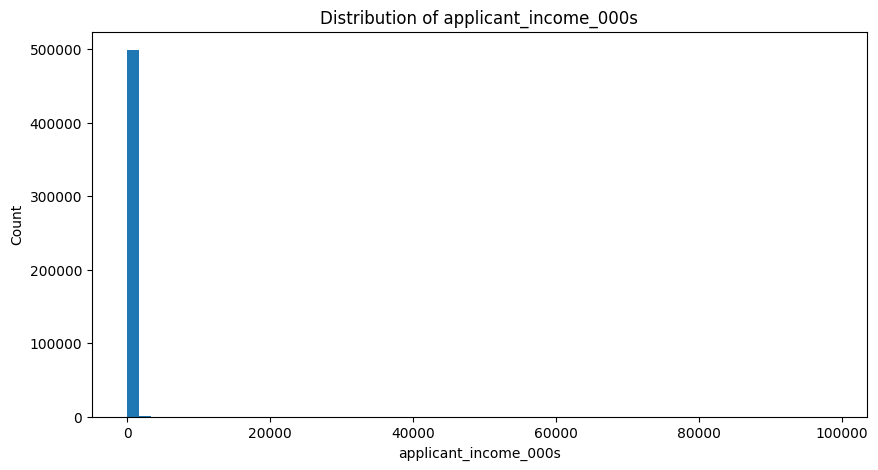

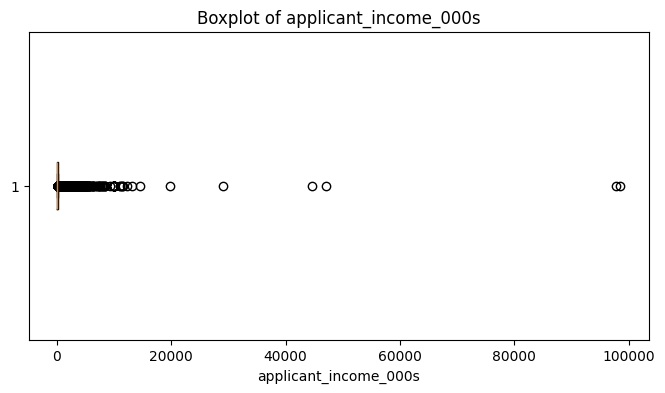

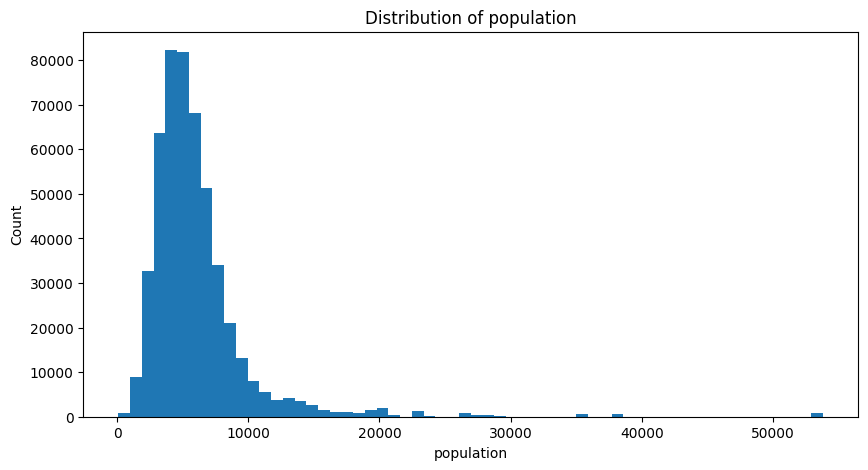

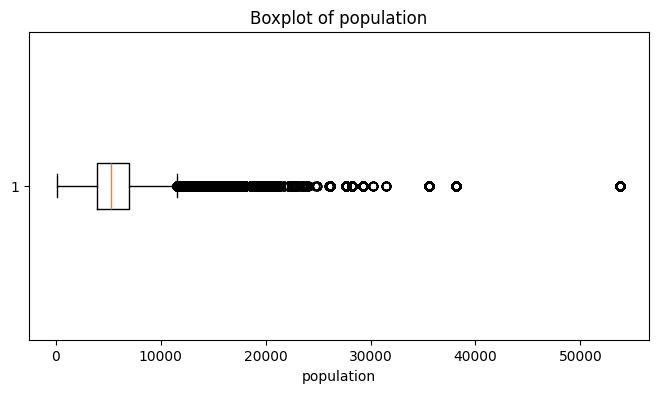

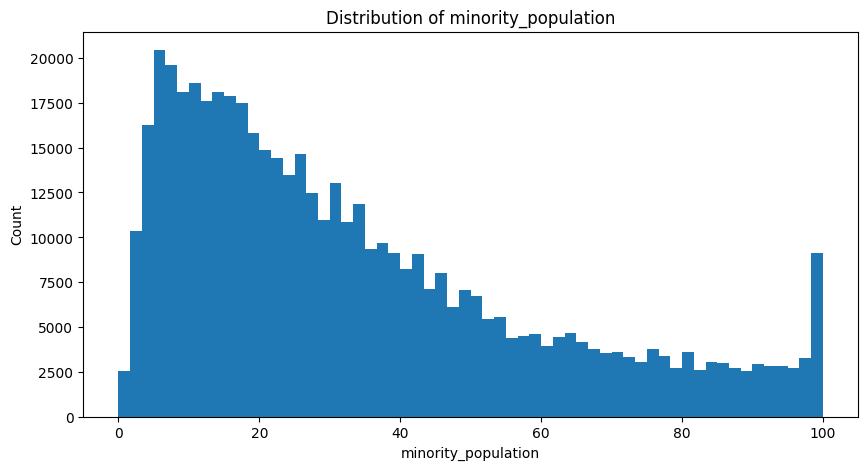

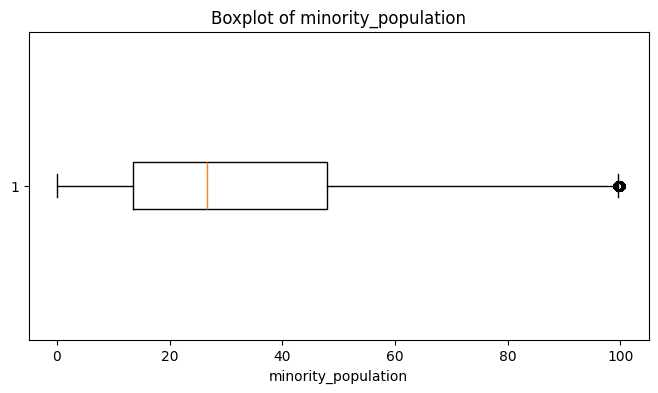

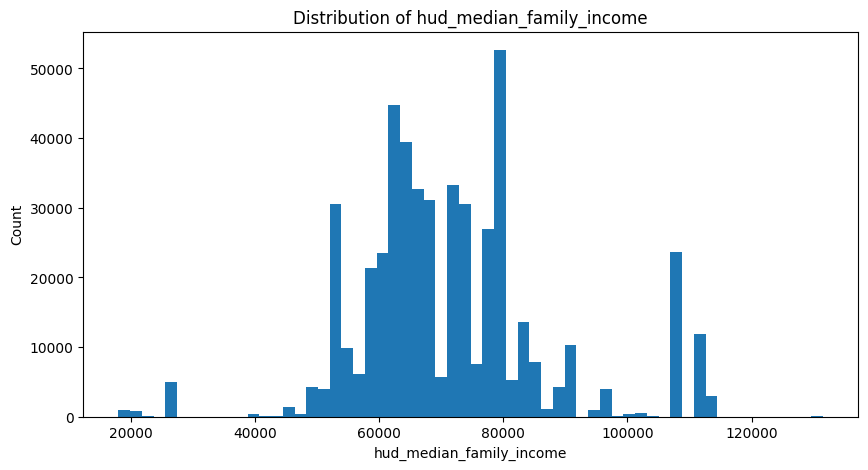

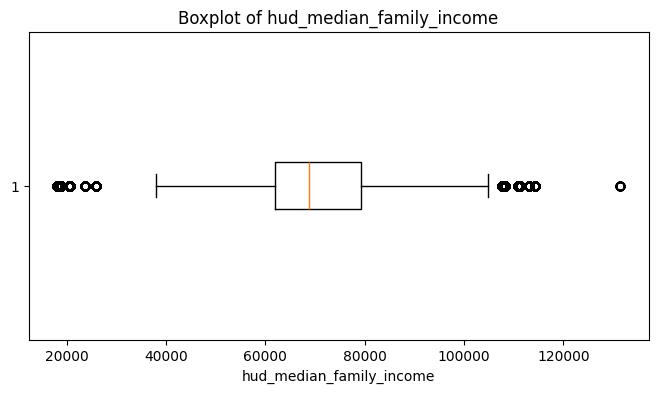

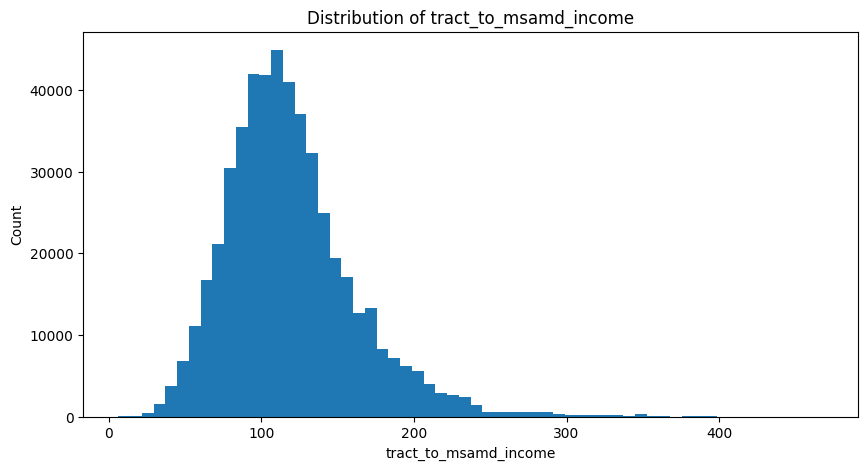

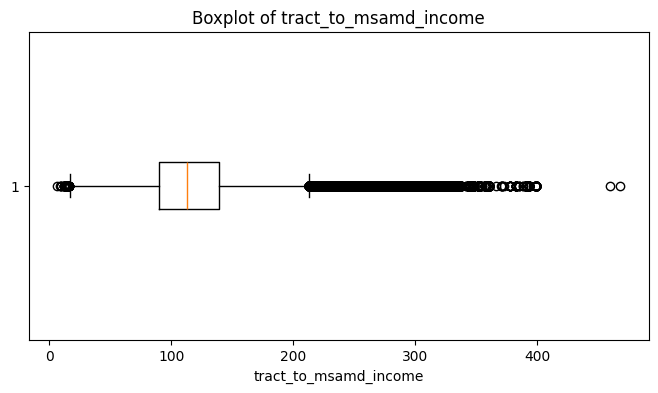

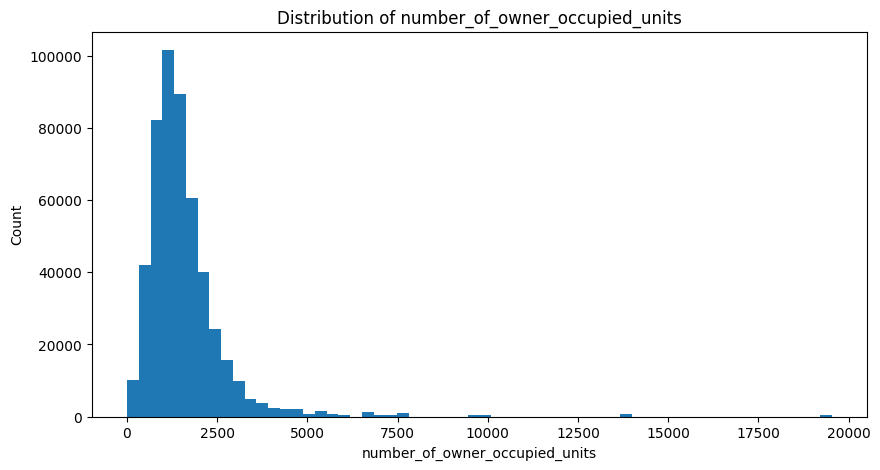

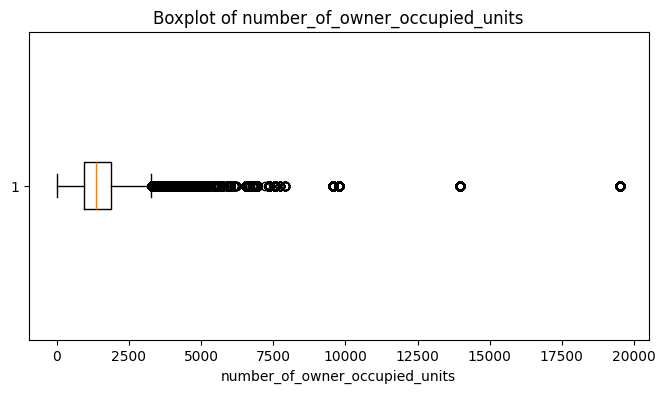

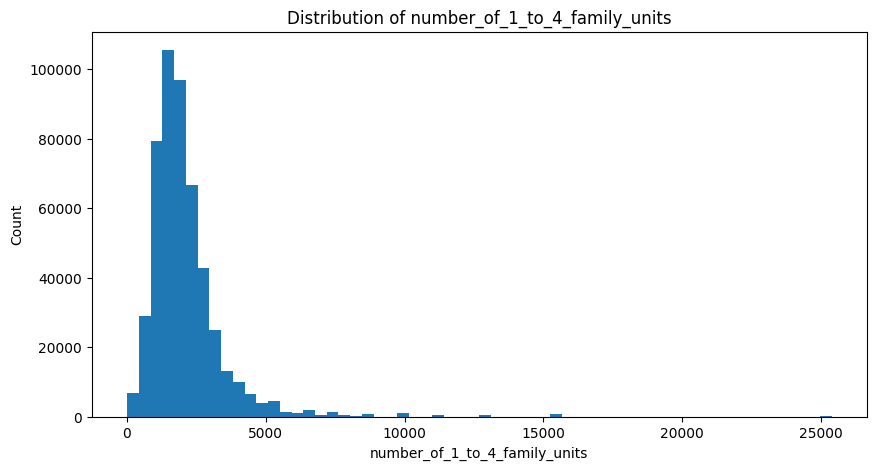

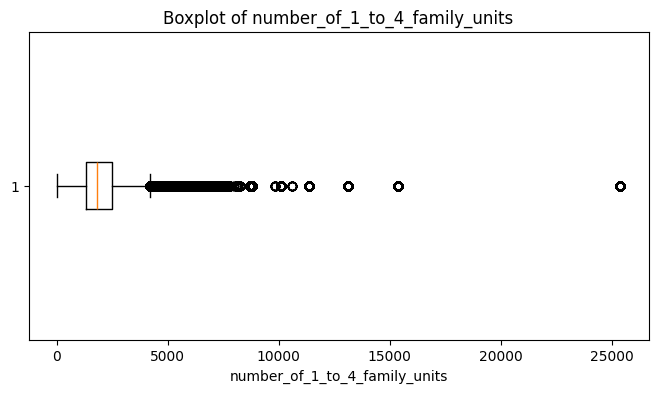

In [10]:
for col in numeric_feature_cols:
    numeric_s = pd.to_numeric(df[col], errors="coerce")
    
    plt.figure(figsize=(10, 5))
    plt.hist(numeric_s.dropna(), bins=60)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()
    
    plt.figure(figsize=(8, 4))
    plt.boxplot(numeric_s.dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

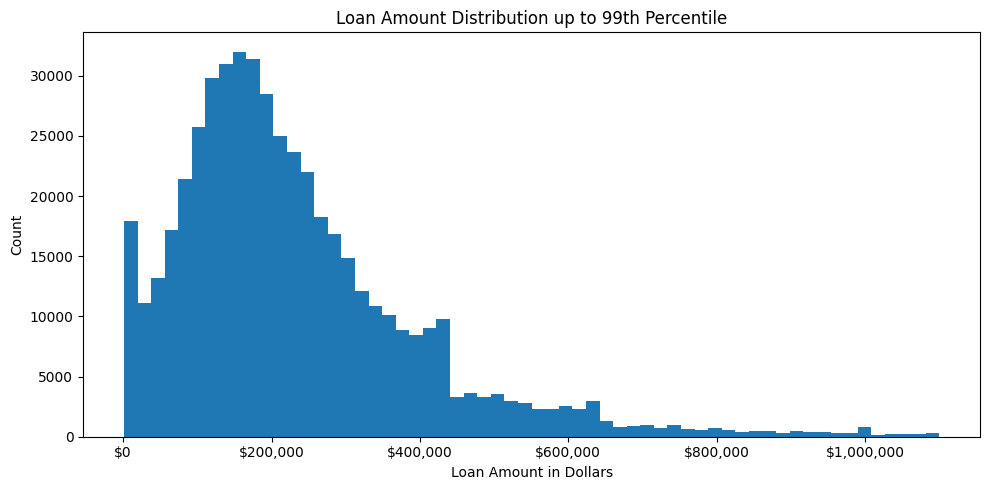

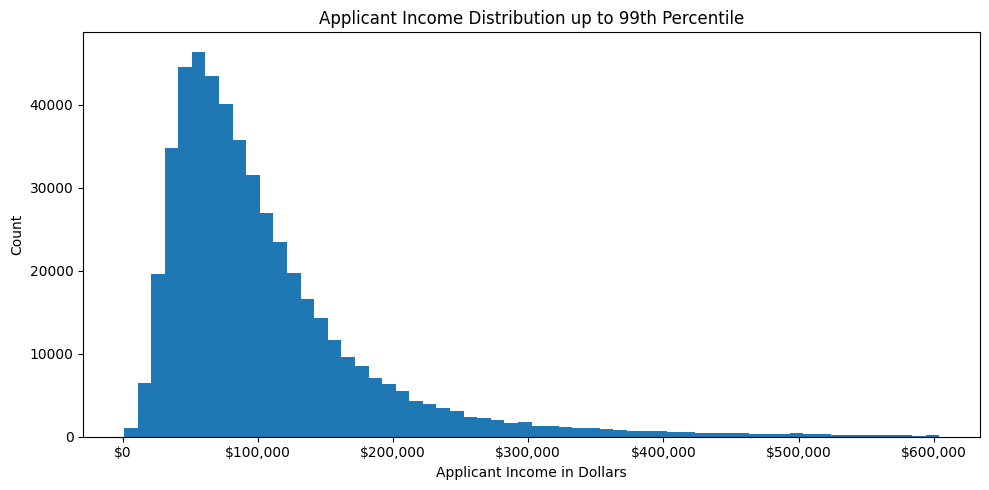

In [11]:
import matplotlib.ticker as ticker

for col, title in [
    ("loan_amount_000s", "Loan Amount"),
    ("applicant_income_000s", "Applicant Income")
]:
    values = pd.to_numeric(df[col], errors="coerce") * 1000
    limit = values.quantile(0.99)

    plt.figure(figsize=(10, 5))
    plt.hist(values[values <= limit].dropna(), bins=60)
    plt.title(f"{title} Distribution up to 99th Percentile")
    plt.xlabel(f"{title} in Dollars")
    plt.ylabel("Count")
    plt.gca().xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
    )
    plt.tight_layout()
    plt.show()

The loan amount and applicant income are stored in thousands of dollars.

We multiply them by 1000 to show the values in dollars.

The histogram is limited to the 99th percentile.

This makes the main distribution easier to read.


# Numeric features and target

We use bins to reduce noise.

For each numeric feature we show median loan amount by bin.

This plot is easier to read than a large scatter plot.

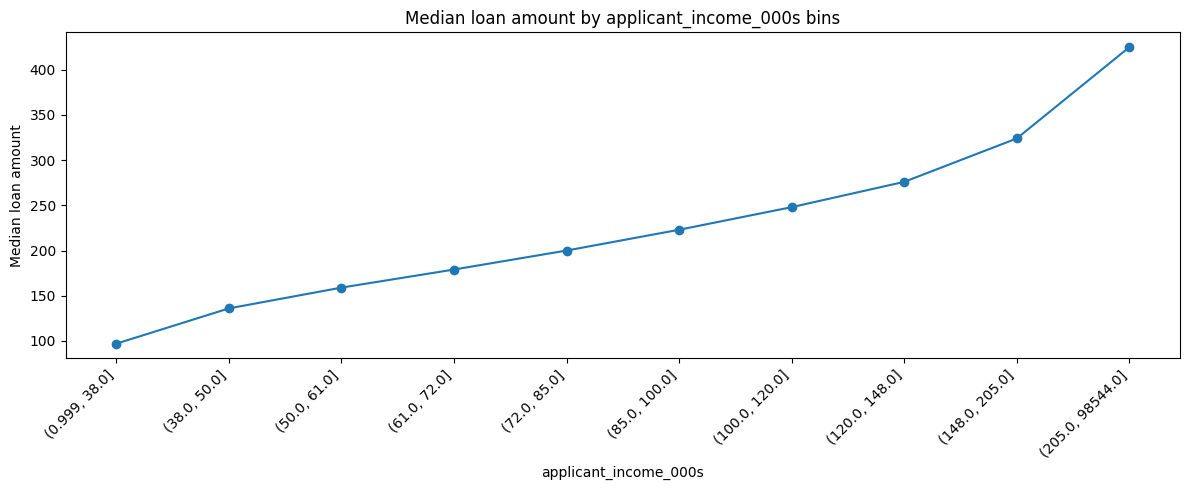

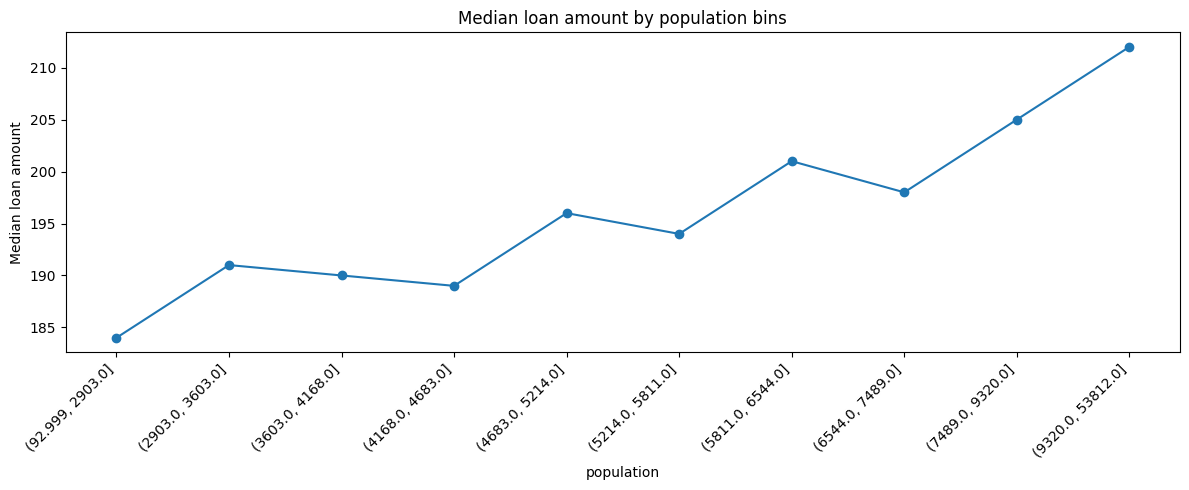

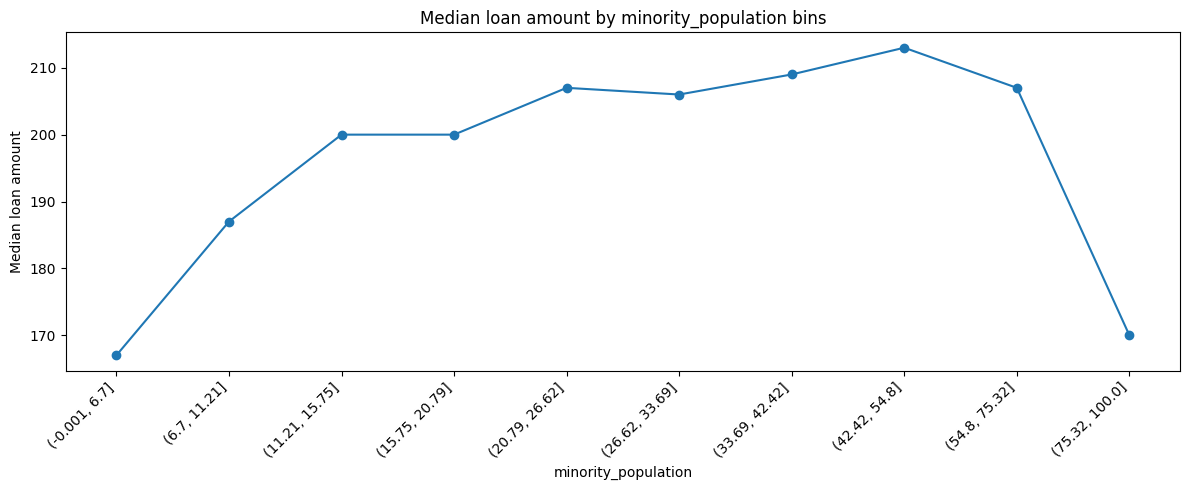

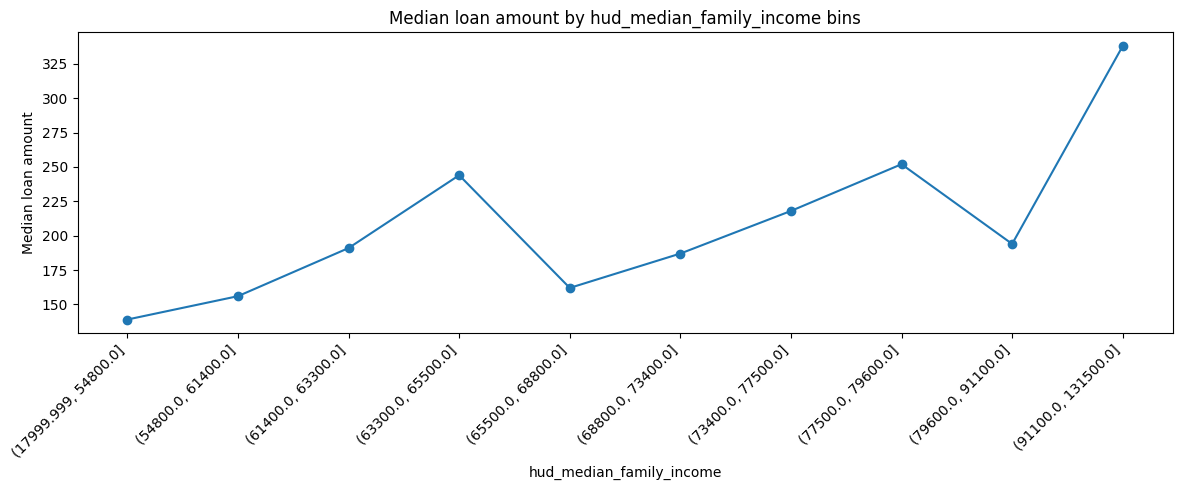

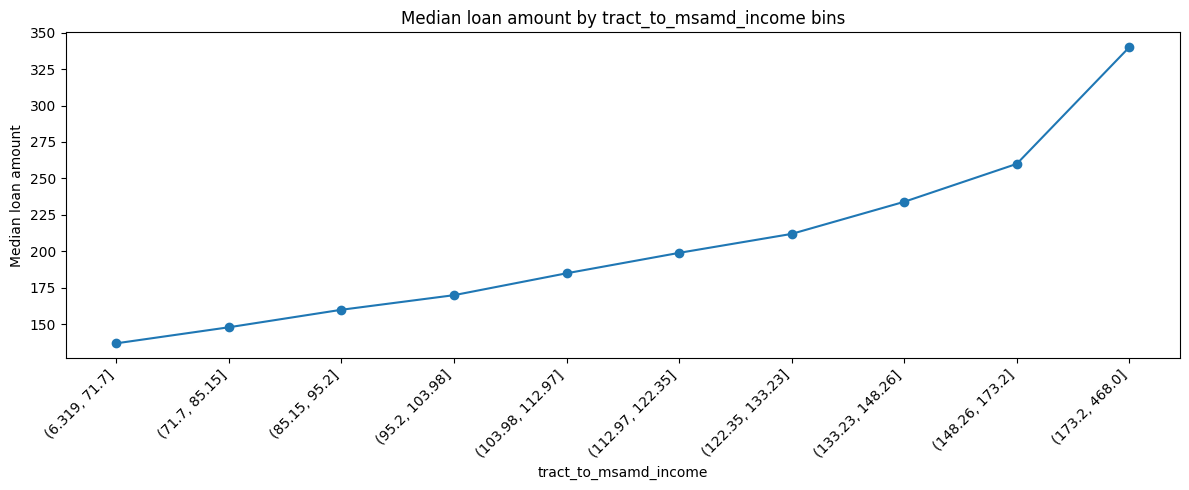

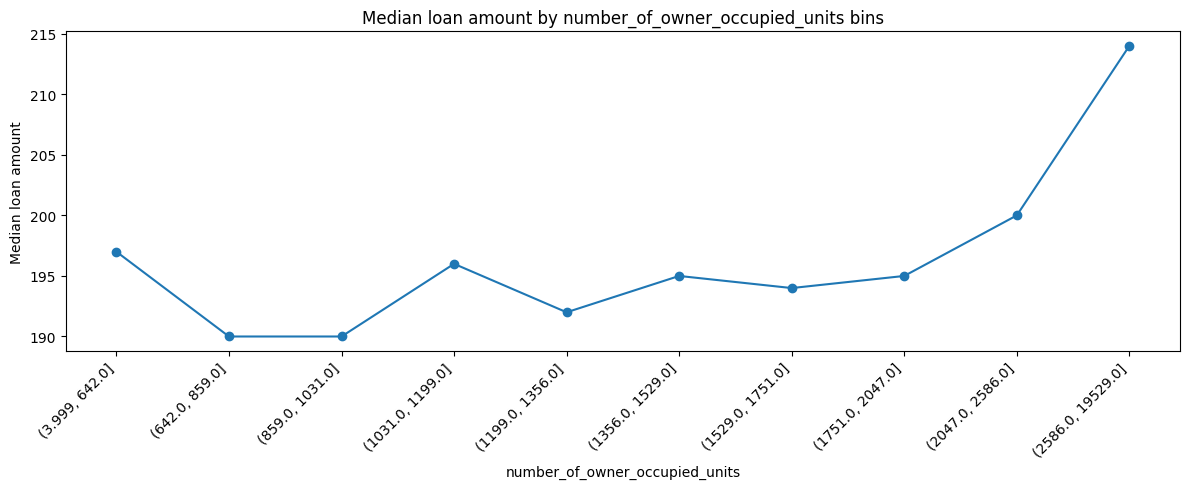

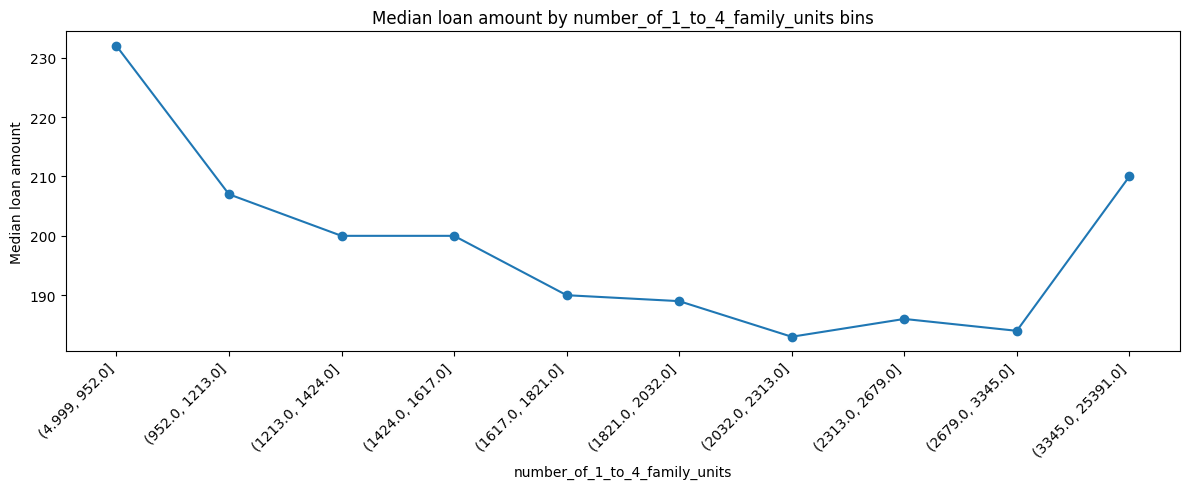

In [12]:
def plot_median_target_by_numeric_bins(data, feature_col, target_col, bins=10):
    temp = data[[feature_col, target_col]].copy()
    temp[feature_col] = pd.to_numeric(temp[feature_col], errors="coerce")
    temp[target_col] = pd.to_numeric(temp[target_col], errors="coerce")
    temp = temp.dropna()
    
    if temp[feature_col].nunique() < 3:
        return
    
    temp["feature_bin"] = pd.qcut(
        temp[feature_col],
        q=bins,
        duplicates="drop"
    )
    
    grouped = (
        temp
        .groupby("feature_bin", observed=False)[target_col]
        .median()
        .reset_index()
    )
    
    grouped["feature_bin"] = grouped["feature_bin"].astype(str)
    
    plt.figure(figsize=(12, 5))
    plt.plot(grouped["feature_bin"], grouped[target_col], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Median loan amount by {feature_col} bins")
    plt.xlabel(feature_col)
    plt.ylabel("Median loan amount")
    plt.tight_layout()
    plt.show()

for col in numeric_feature_cols:
    plot_median_target_by_numeric_bins(df, col, TARGET_COL, bins=10)

# Scatter plots on a small sample

Scatter plots are useful but the full data is large.

We use a small sample to reduce overplotting.

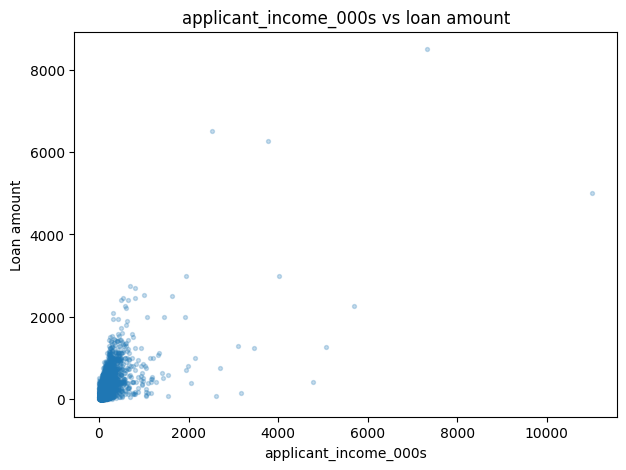

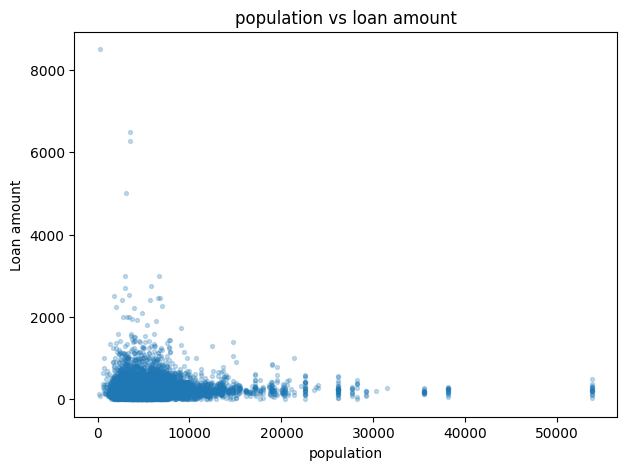

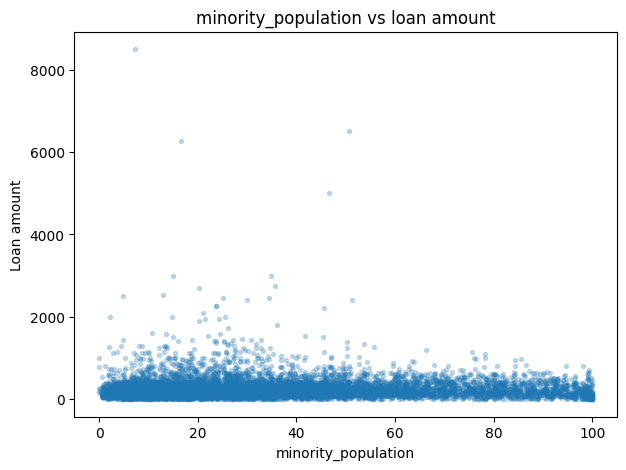

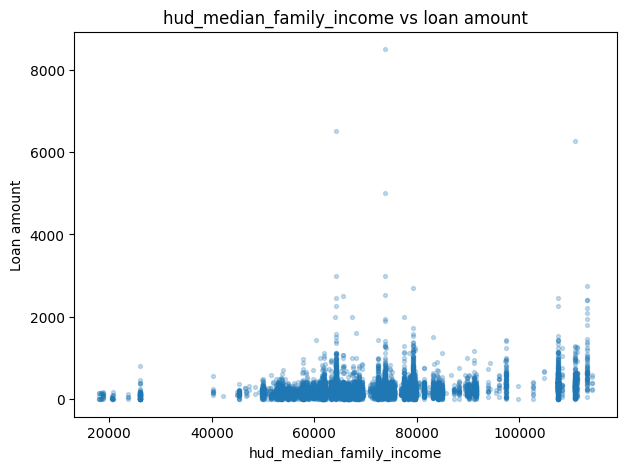

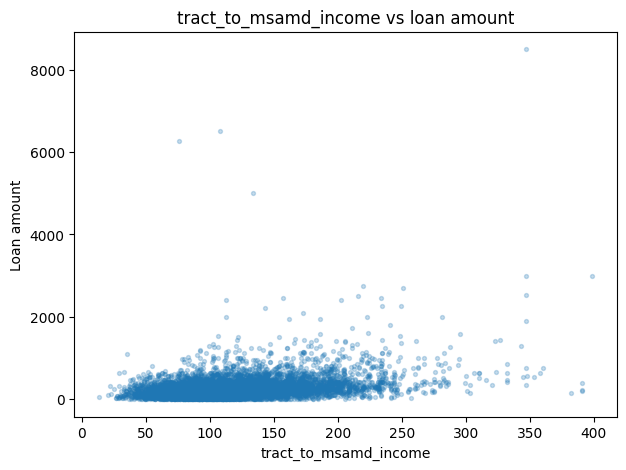

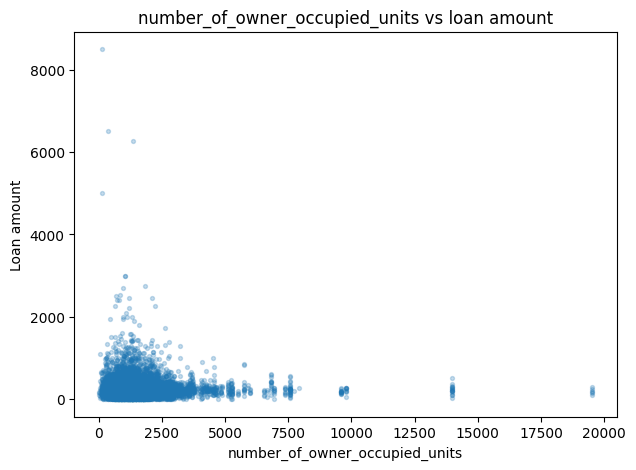

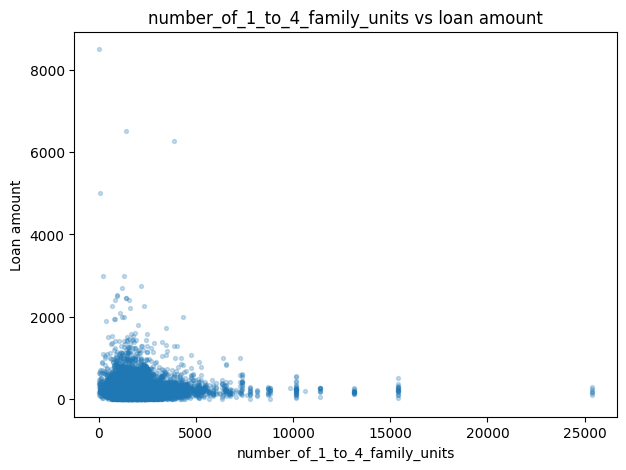

In [13]:
plot_sample = df.sample(
    n=min(PLOT_SAMPLE_SIZE, len(df)),
    random_state=RANDOM_STATE
).copy()

for col in numeric_feature_cols:
    plot_sample[col] = pd.to_numeric(plot_sample[col], errors="coerce")
    
    plt.figure(figsize=(7, 5))
    plt.scatter(
        plot_sample[col],
        plot_sample[TARGET_COL],
        alpha=0.25,
        s=8
    )
    plt.title(f"{col} vs loan amount")
    plt.xlabel(col)
    plt.ylabel("Loan amount")
    plt.show()

# Pairplot

A pairplot helps us see simple relations.

We use a small sample because the full data is large.

This is only for exploration.

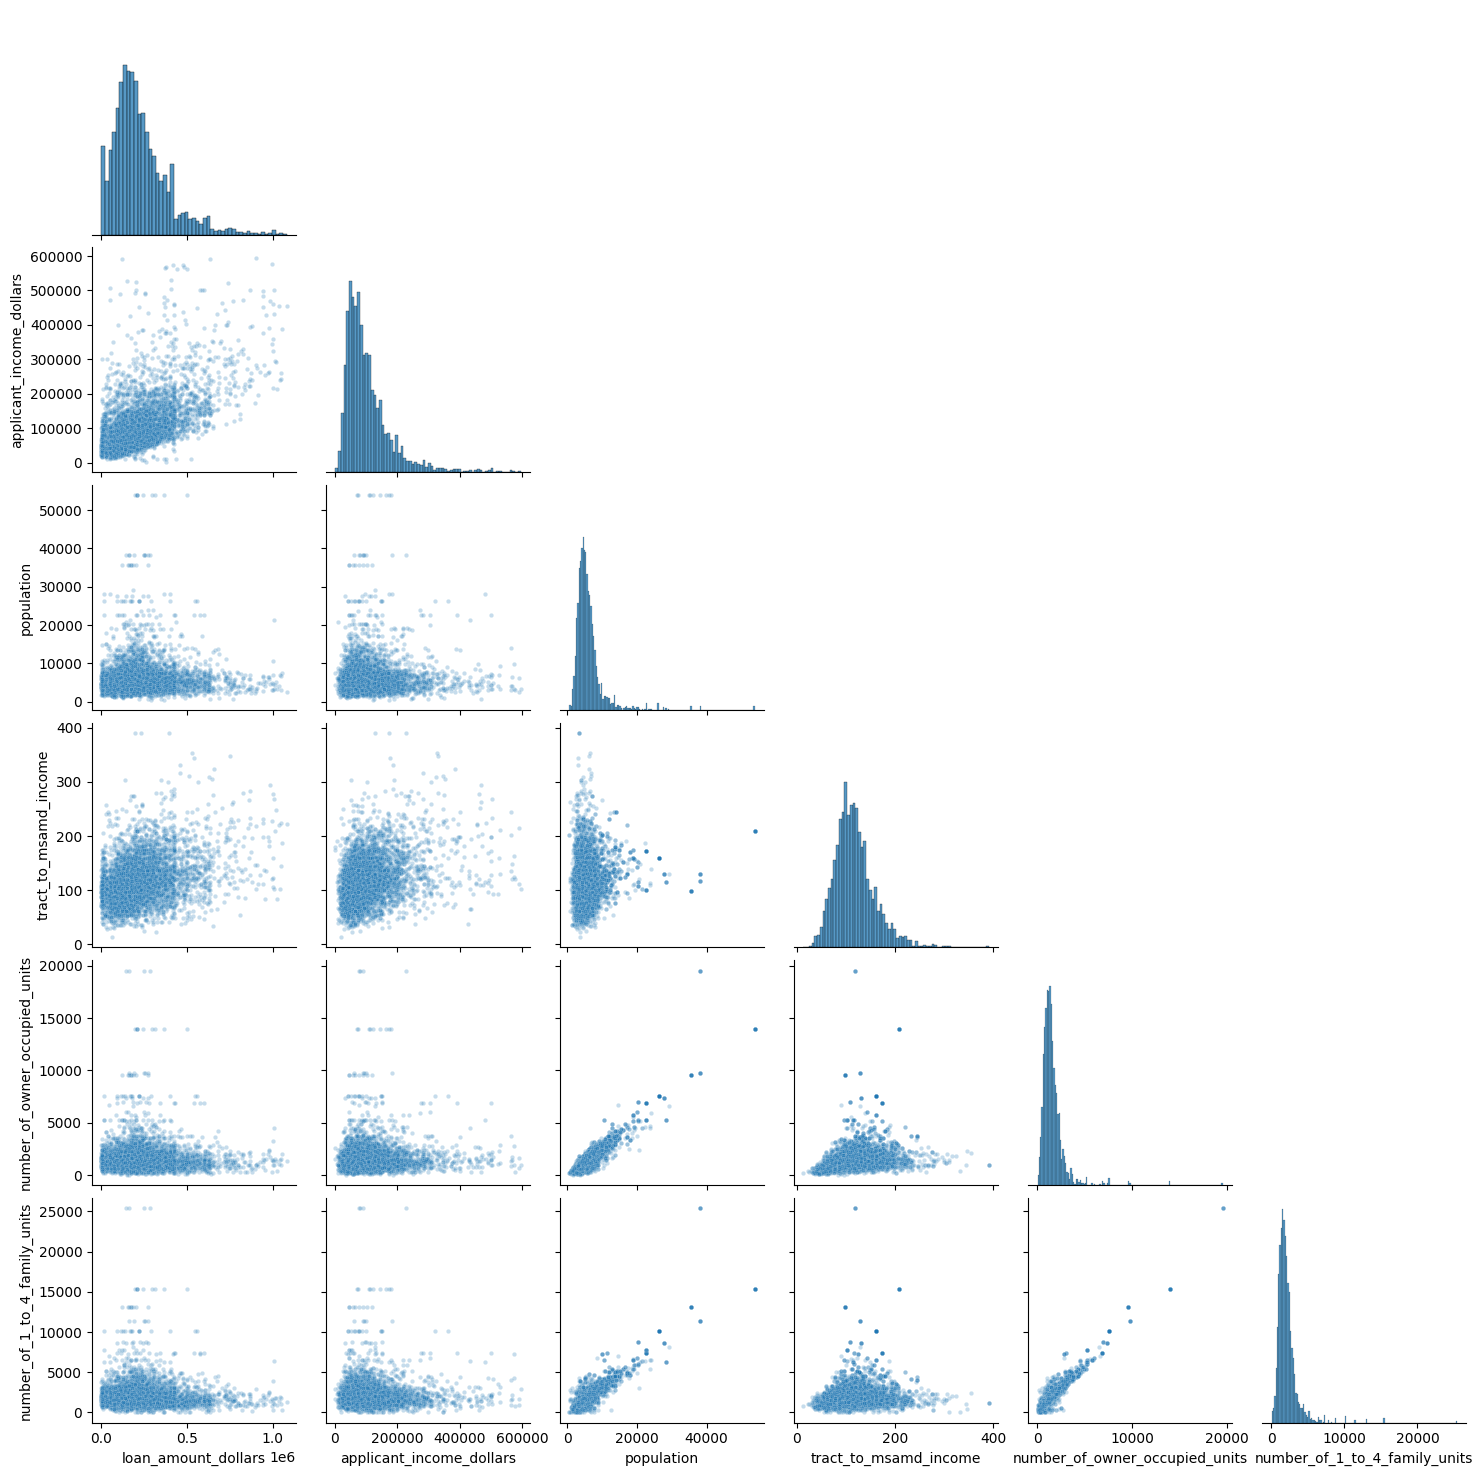

In [14]:
pairplot_cols = [
   "loan_amount_000s",

    "applicant_income_000s",

    "population",

    "minority_population",

    "hud_median_family_income",

    "tract_to_msamd_income",

    "number_of_owner_occupied_units",

    "number_of_1_to_4_family_units"
]

pairplot_cols = [col for col in pairplot_cols if col in df.columns]

pairplot_sample = df[pairplot_cols].sample(
    n=min(5000, len(df)),
    random_state=RANDOM_STATE
).copy()

for col in pairplot_cols:
    pairplot_sample[col] = pd.to_numeric(pairplot_sample[col], errors="coerce")

money_cols = {
    "loan_amount_000s": "loan_amount_dollars",
    "applicant_income_000s": "applicant_income_dollars"
}

for old_col, new_col in money_cols.items():
    limit = pd.to_numeric(df[old_col], errors="coerce").quantile(0.99) * 1000
    pairplot_sample[new_col] = pairplot_sample[old_col] * 1000
    pairplot_sample = pairplot_sample[pairplot_sample[new_col] <= limit]
    pairplot_sample = pairplot_sample.drop(columns=old_col)

final_pairplot_cols = [
    "loan_amount_dollars",
    "applicant_income_dollars",
    "population",
    "tract_to_msamd_income",
    "number_of_owner_occupied_units",
    "number_of_1_to_4_family_units"
]

final_pairplot_cols = [col for col in final_pairplot_cols if col in pairplot_sample.columns]

pairplot_sample = pairplot_sample[final_pairplot_cols].dropna()

sns.pairplot(
    pairplot_sample,
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.25, "s": 10}
)

plt.show()

# Correlation analysis

We check linear relations between numeric columns.

This does not show all relations.

It is still useful for a first view.

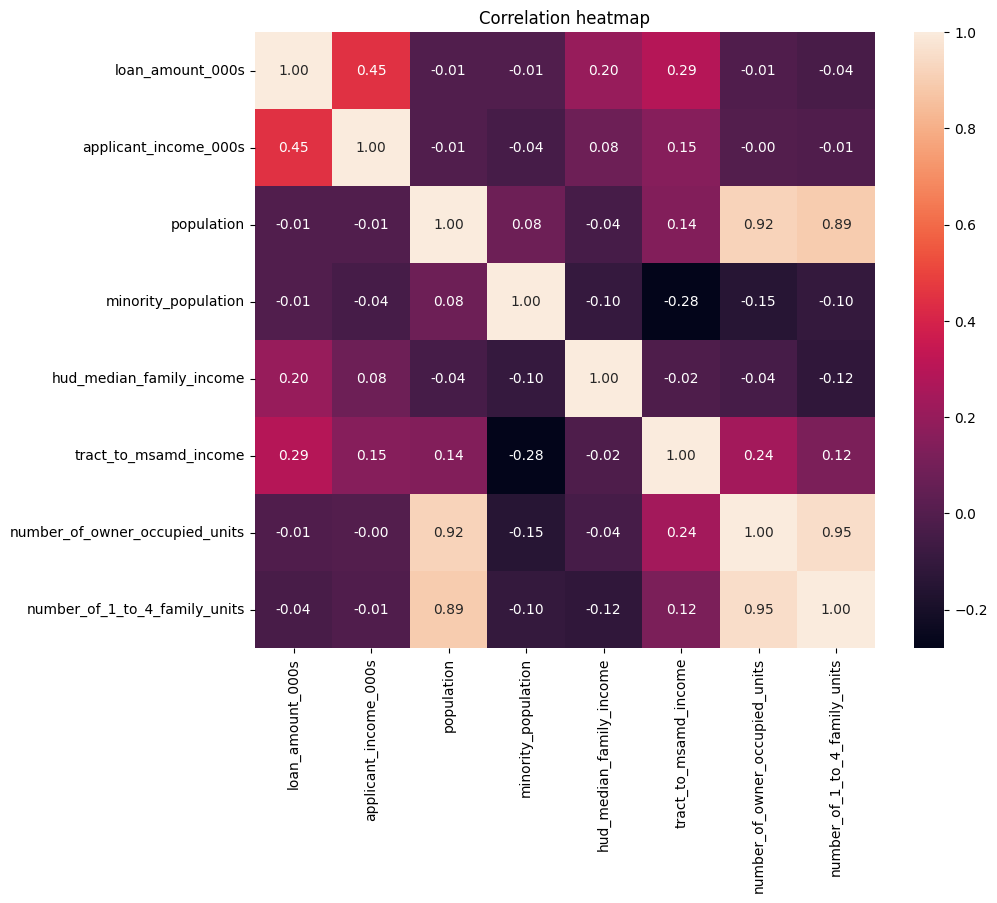

In [15]:
corr_df = df[pairplot_cols].apply(pd.to_numeric, errors="coerce").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

# Categorical feature analysis

We now study categorical features.

For each feature we check group size.

We also check the median loan amount by group.

Feature: agency_name


,agency_name,count,mean_loan_amount,median_loan_amount,percent
1,Department of Housing and Urban Development,263038,242.167462,209.0,52.64
0,Consumer Financial Protection Bureau,119009,303.239125,202.0,23.81
2,Federal Deposit Insurance Corporation,44014,211.060299,173.0,8.81
4,National Credit Union Administration,42375,163.087670,120.0,8.48
5,Office of the Comptroller of the Currency,16880,236.039396,184.0,3.38
3,Federal Reserve System,14420,246.539182,200.0,2.89


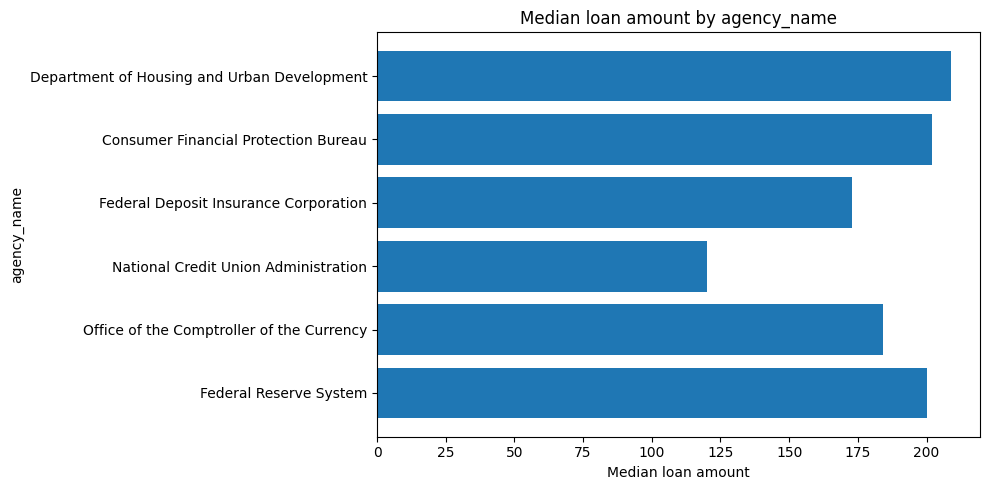

Feature: loan_type_name


,loan_type_name,count,mean_loan_amount,median_loan_amount,percent
0,Conventional,370801,255.209948,198.0,74.20
1,FHA-insured,79993,203.376095,182.0,16.01
3,VA-guaranteed,41562,276.934459,243.0,8.32
2,FSA/RHS-guaranteed,7380,151.300813,146.0,1.48


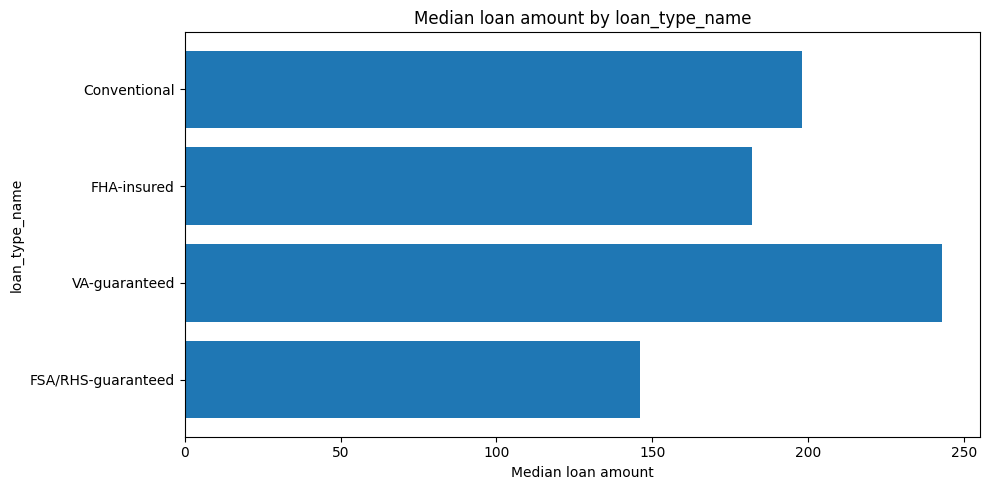

Feature: property_type_name


,property_type_name,count,mean_loan_amount,median_loan_amount,percent
1,One-to-four family dwelling (other than manufa...,490783,250.296208,200.0,98.21
0,Manufactured housing,8953,76.644030,63.0,1.79


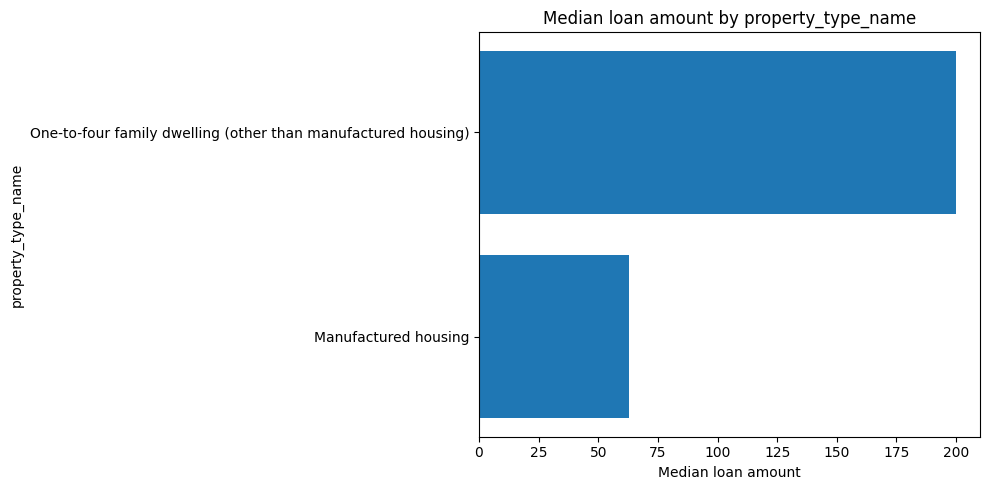

Feature: loan_purpose_name


,loan_purpose_name,count,mean_loan_amount,median_loan_amount,percent
1,Home purchase,294131,264.917377,213.0,58.86
2,Refinancing,167777,246.796754,191.0,33.57
0,Home improvement,37828,111.031141,38.0,7.57


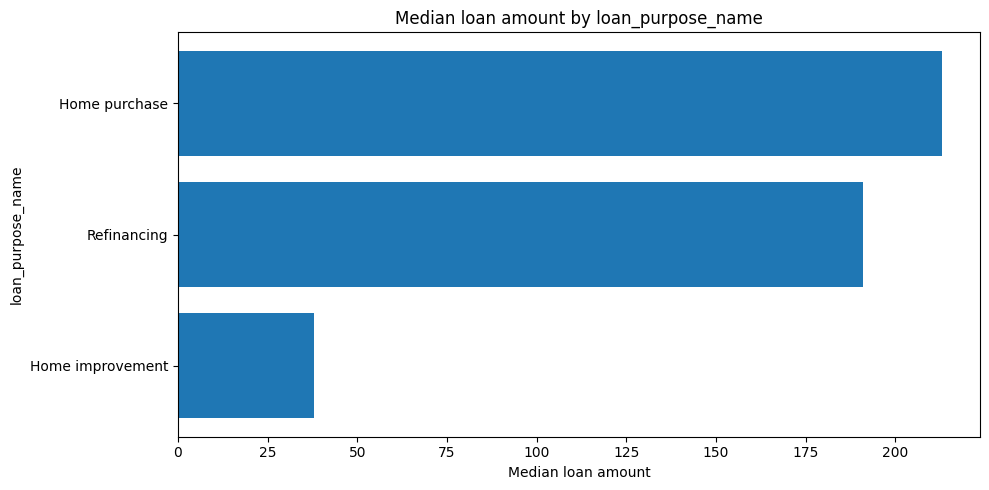

Feature: owner_occupancy_name


,owner_occupancy_name,count,mean_loan_amount,median_loan_amount,percent
2,Owner-occupied as a principal dwelling,455008,247.737093,200.0,91.05
1,Not owner-occupied as a principal dwelling,44527,241.751814,169.0,8.91
0,Not applicable,201,201.373134,122.0,0.04


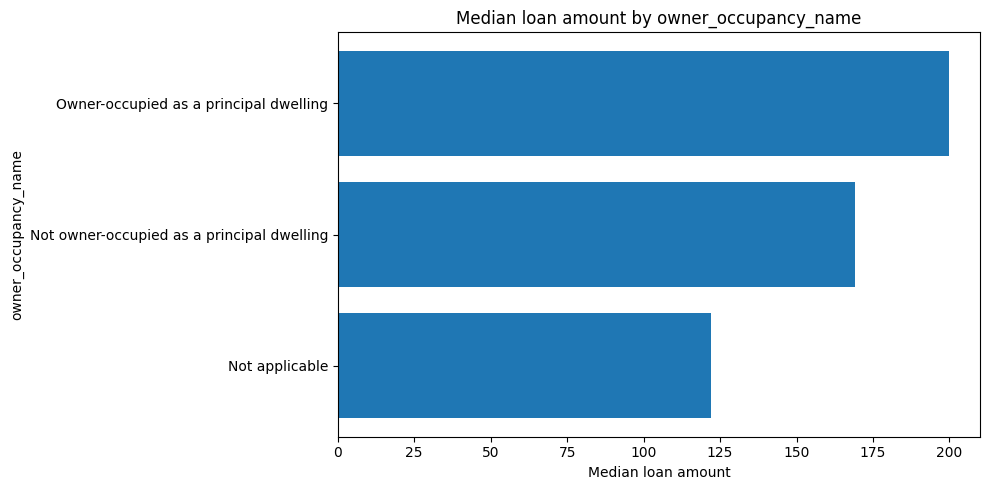

Feature: preapproval_name


,preapproval_name,count,mean_loan_amount,median_loan_amount,percent
0,Not applicable,380352,244.589851,192.0,76.11
1,Preapproval was not requested,101732,252.011796,208.0,20.36
2,Preapproval was requested,17652,275.289769,217.0,3.53


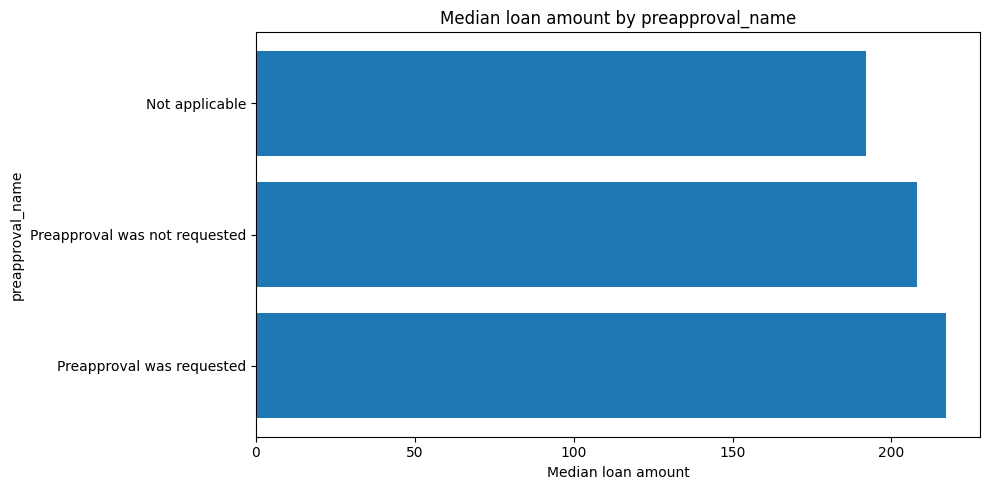

Feature: state_name


,state_name,count,mean_loan_amount,median_loan_amount,percent
4,California,76577,400.313057,340.0,15.32
9,Florida,39351,209.098854,183.0,7.87
13,Illinois,34722,218.991590,183.0,6.95
44,Texas,34086,218.128000,185.0,6.82
22,Michigan,33272,172.135970,145.0,6.66
47,Virginia,32342,322.698132,280.0,6.47
32,New York,29002,331.042480,268.0,5.80
41,South Carolina,28492,205.525516,172.0,5.70
28,Nevada,24394,235.395179,213.0,4.88
0,Alabama,22894,164.449594,142.0,4.58


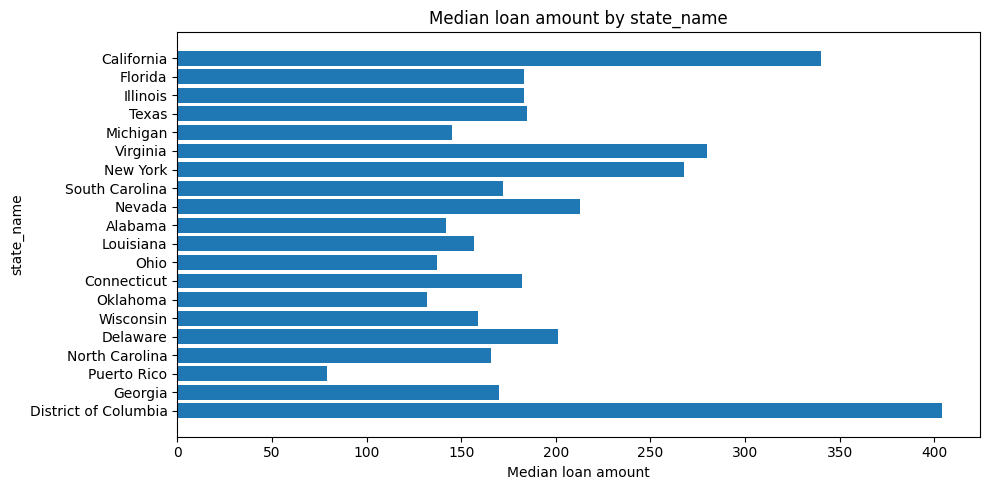

Feature: county_name


,county_name,count,mean_loan_amount,median_loan_amount,percent
699,San Diego County,26416,441.146275,400.0,5.29
179,Clark County,22447,231.499354,209.0,4.49
469,Los Angeles County,17696,490.030515,411.0,3.54
571,Oakland County,12908,217.997366,185.0,2.58
350,Harris County,12117,220.067508,170.0,2.42
248,DuPage County,11255,273.260506,228.0,2.25
773,Suffolk County,10151,337.851443,294.0,2.03
274,Fairfax County,9957,440.919655,391.0,1.99
418,Kern County,8579,189.545168,183.0,1.72
293,Fort Bend County,7409,254.753813,237.0,1.48


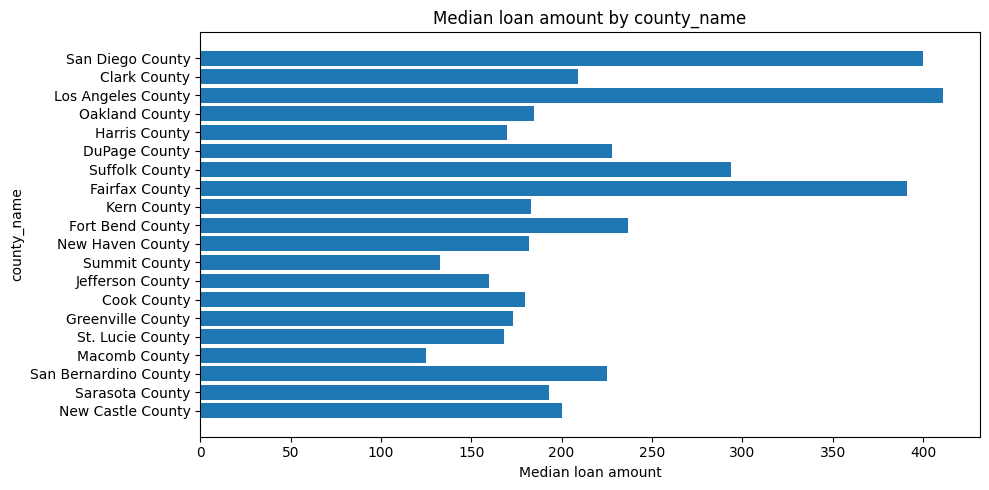

Feature: msamd_name


,msamd_name,count,mean_loan_amount,median_loan_amount,percent
324,"San Diego, Carlsbad - CA",26416,441.146275,400.0,5.29
170,"Houston, The Woodlands, Sugar Land - TX",23648,230.043471,193.0,4.73
388,"Washington, Arlington, Alexandria - DC, VA, MD...",22635,411.863928,363.0,4.53
209,"Las Vegas, Henderson, Paradise - NV",22078,231.597246,209.0,4.42
73,"Chicago, Naperville, Arlington Heights - IL",20493,245.685893,206.0,4.10
387,"Warren, Troy, Farmington Hills - MI",19013,192.294903,161.0,3.80
222,"Los Angeles, Long Beach, Glendale - CA",17696,490.030515,411.0,3.54
264,"New York, Jersey City, White Plains - NY, NJ",11066,446.773902,360.0,2.21
260,"Nassau County, Suffolk County - NY",10561,339.429315,295.0,2.11
25,Bakersfield - CA,8579,189.545168,183.0,1.72


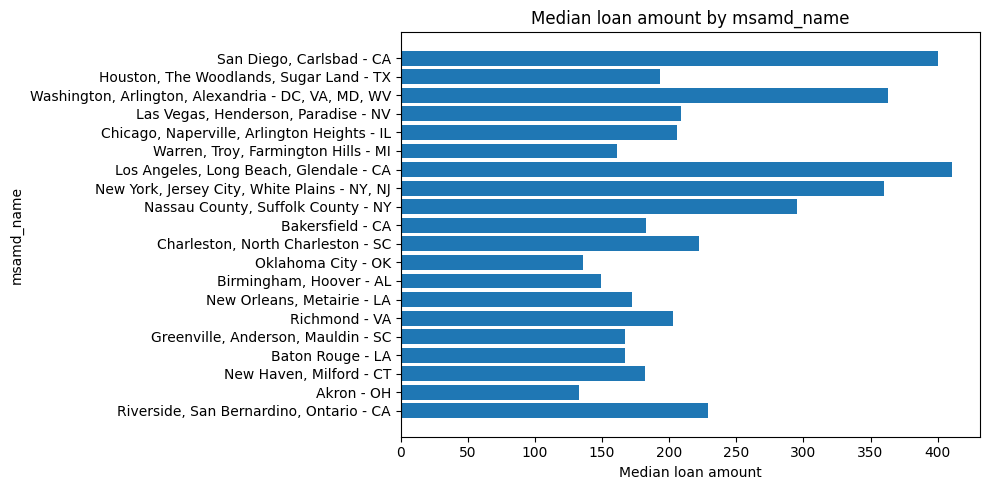

Feature: lien_status_name


,lien_status_name,count,mean_loan_amount,median_loan_amount,percent
1,Secured by a first lien,468450,261.462641,207.0,93.74
2,Secured by a subordinate lien,16329,51.100557,32.0,3.27
0,Not secured by a lien,14957,14.088587,10.0,2.99


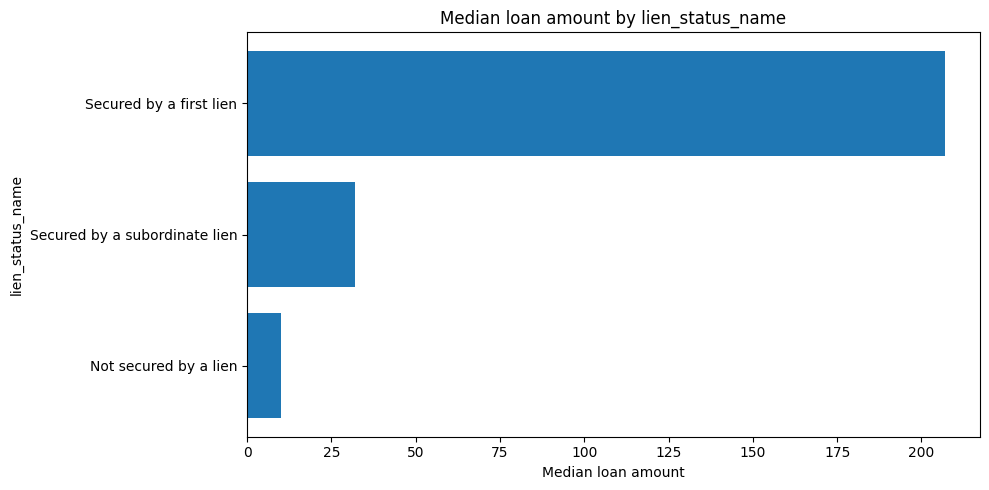

In [16]:
def categorical_target_summary(data, feature_col, target_col, top_n=20):
    temp = data[[feature_col, target_col]].copy()
    temp[target_col] = pd.to_numeric(temp[target_col], errors="coerce")
    
    summary = (
        temp
        .groupby(feature_col, dropna=False)
        .agg(
            count=(target_col, "size"),
            mean_loan_amount=(target_col, "mean"),
            median_loan_amount=(target_col, "median")
        )
        .reset_index()
    )
    
    summary["percent"] = (summary["count"] / len(temp) * 100).round(2)
    summary = summary.sort_values("count", ascending=False).head(top_n)
    
    return summary

for col in categorical_cols:
    print("=" * 100)
    print("Feature:", col)
    
    summary = categorical_target_summary(df, col, TARGET_COL, top_n=20)
    display(summary)
    
    plt.figure(figsize=(10, 5))
    plt.barh(summary[col].astype(str), summary["median_loan_amount"])
    plt.gca().invert_yaxis()
    plt.title(f"Median loan amount by {col}")
    plt.xlabel("Median loan amount")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Boxplots for key categorical features

Boxplots show the spread of loan amounts.

We use log loan amount to make the plots easier to read.

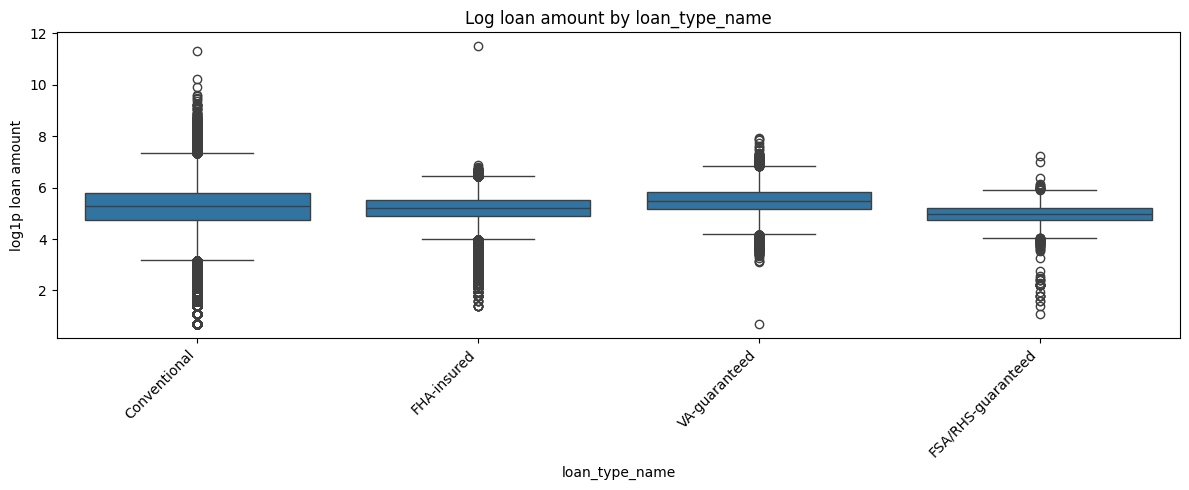

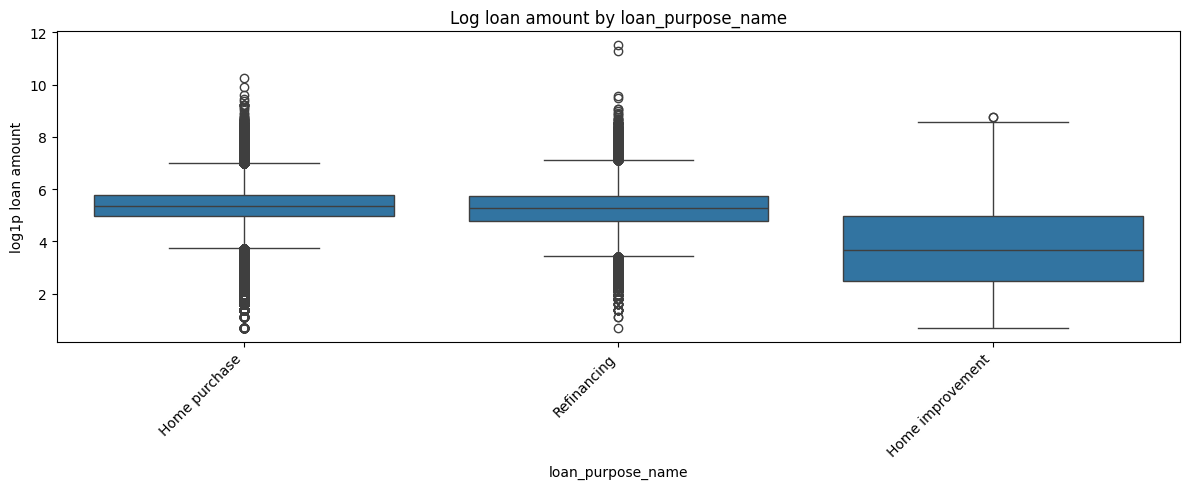

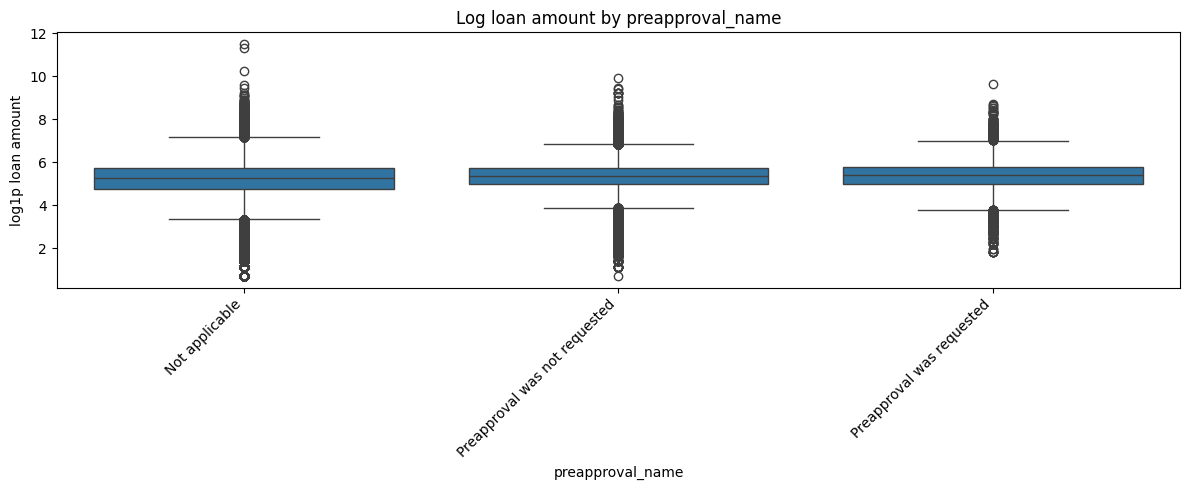

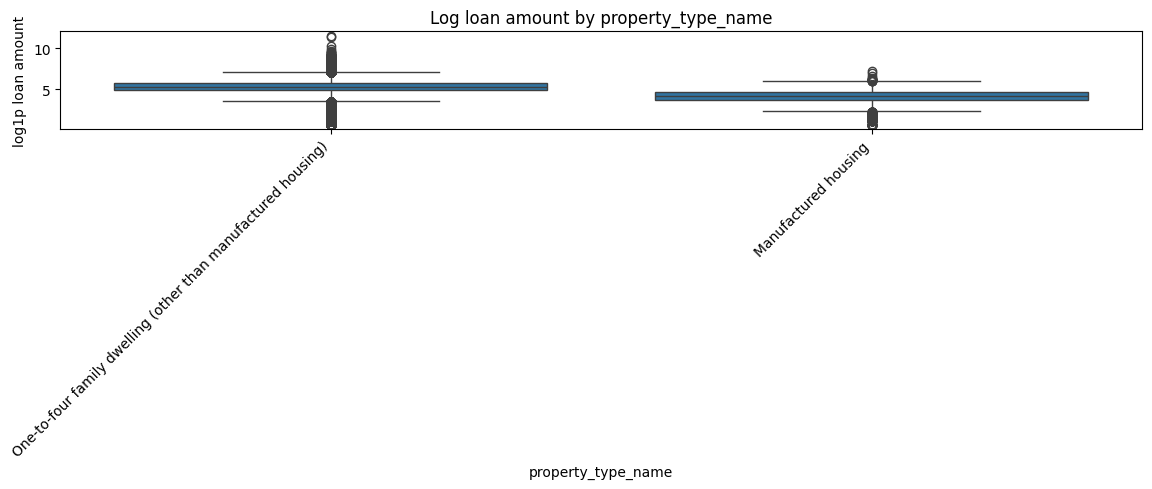

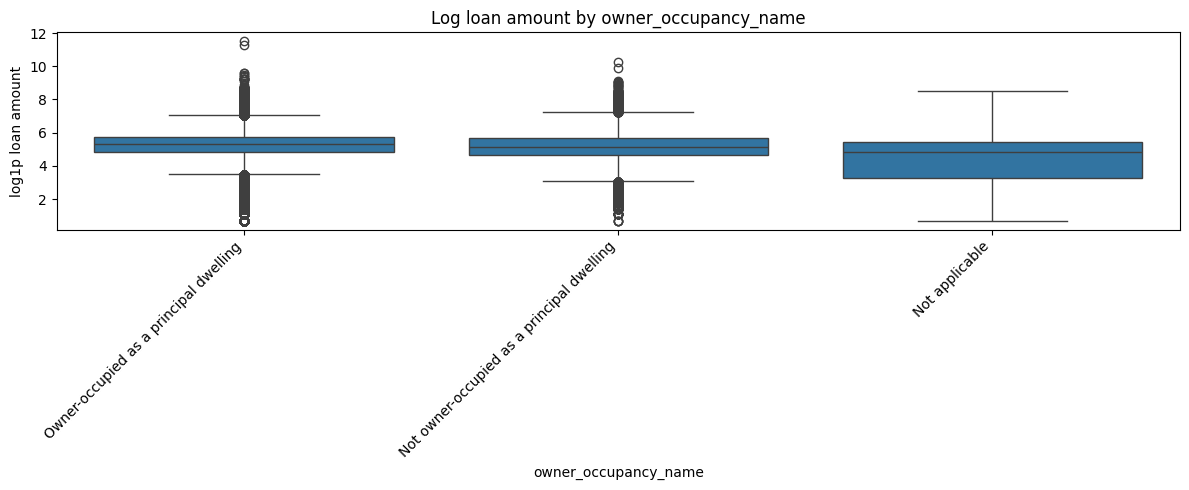

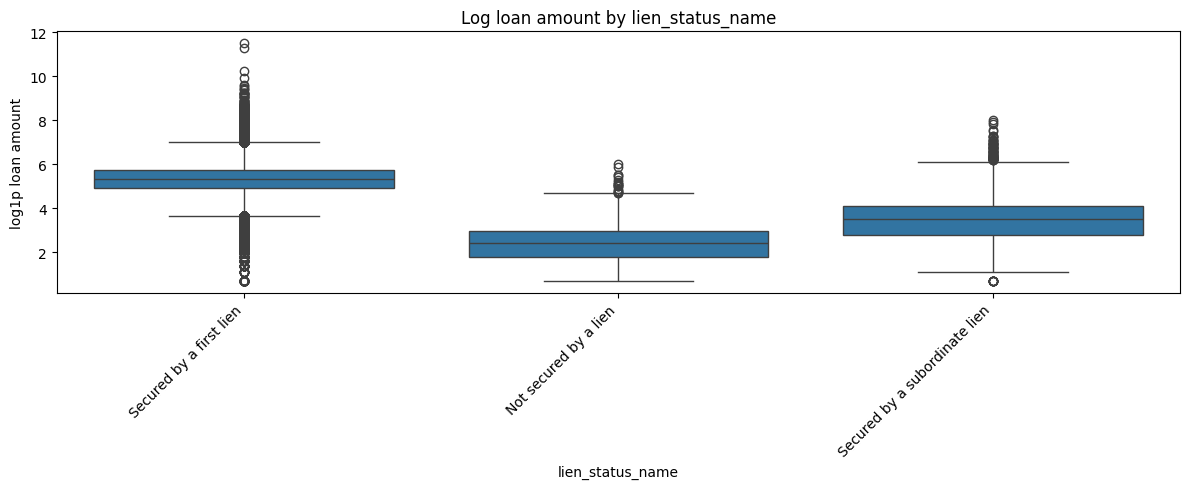

In [17]:
key_categorical_cols = [
    "loan_type_name",
    "loan_purpose_name",
    "preapproval_name",
    "property_type_name",
    "owner_occupancy_name",
    "lien_status_name"
]

key_categorical_cols = [
    col for col in key_categorical_cols
    if col in df.columns
]

for col in key_categorical_cols:
    top_values = df[col].value_counts().head(10).index
    
    temp = df[df[col].isin(top_values)].copy()
    temp["log1p_loan_amount_for_eda"] = np.log1p(
        pd.to_numeric(temp[TARGET_COL], errors="coerce")
    )
    
    plt.figure(figsize=(12, 5))
    sns.boxplot(
        data=temp,
        x=col,
        y="log1p_loan_amount_for_eda"
    )
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Log loan amount by {col}")
    plt.xlabel(col)
    plt.ylabel("log1p loan amount")
    plt.tight_layout()
    plt.show()

# Geographic analysis

Location can strongly affect loan amount.

We check state and metro area patterns.

We focus on groups with enough records.

,state_name,count,median_loan_amount,mean_loan_amount
4,California,76577,340.0,400.313057
9,Florida,39351,183.0,209.098854
13,Illinois,34722,183.0,218.991590
44,Texas,34086,185.0,218.128000
22,Michigan,33272,145.0,172.135970
47,Virginia,32342,280.0,322.698132
32,New York,29002,268.0,331.042480
41,South Carolina,28492,172.0,205.525516
28,Nevada,24394,213.0,235.395179
0,Alabama,22894,142.0,164.449594


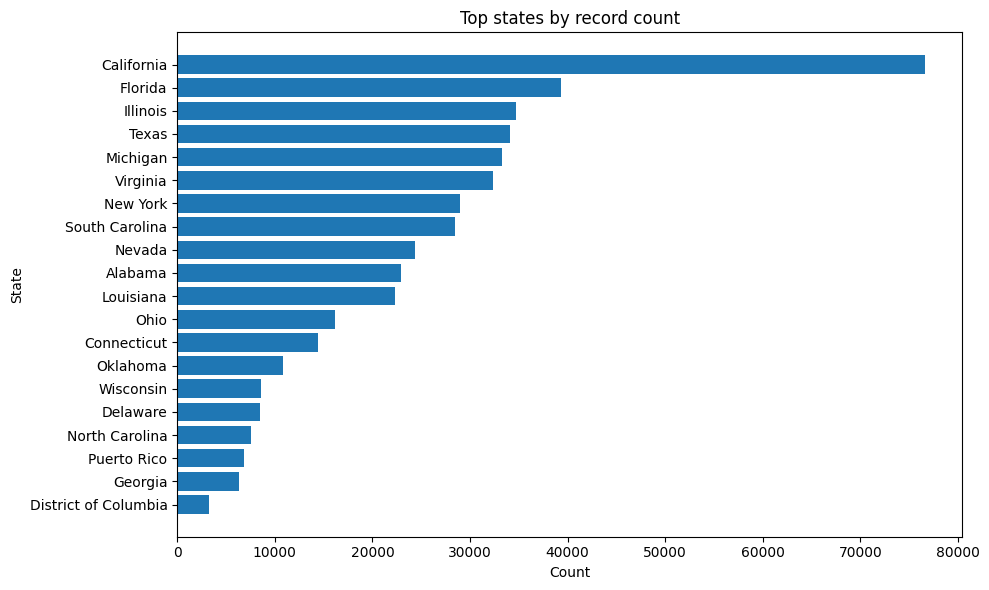

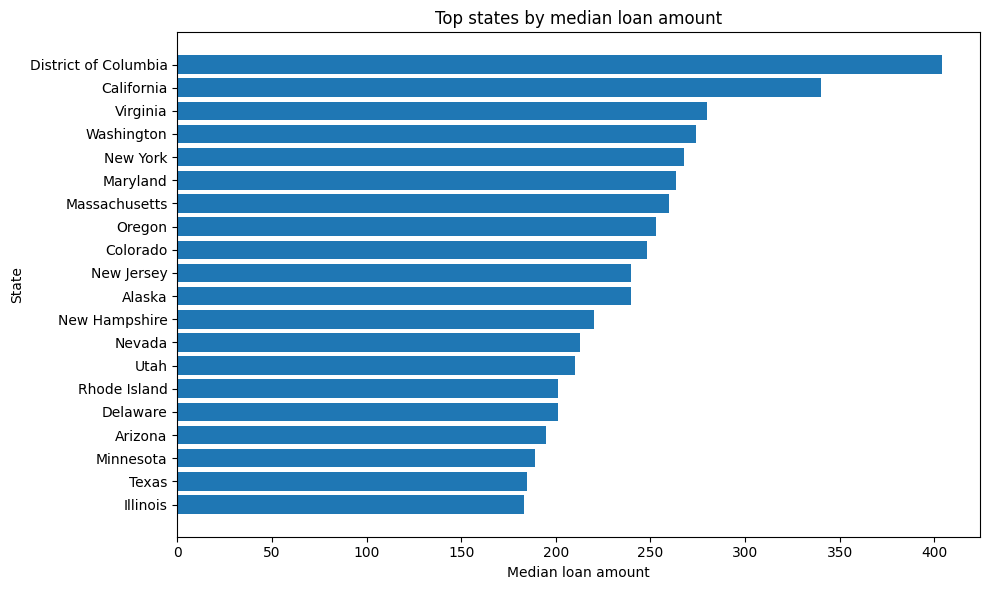

In [18]:
if "state_name" in df.columns:
    state_summary = (
        df
        .groupby("state_name")
        .agg(
            count=(TARGET_COL, "size"),
            median_loan_amount=(TARGET_COL, "median"),
            mean_loan_amount=(TARGET_COL, "mean")
        )
        .reset_index()
        .sort_values("count", ascending=False)
    )
    
    display(state_summary.head(20))
    
    top_states = state_summary.head(20)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_states["state_name"], top_states["count"])
    plt.gca().invert_yaxis()
    plt.title("Top states by record count")
    plt.xlabel("Count")
    plt.ylabel("State")
    plt.tight_layout()
    plt.show()
    
    top_states_by_median = state_summary[state_summary["count"] >= 500].sort_values(
        "median_loan_amount",
        ascending=False
    ).head(20)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_states_by_median["state_name"], top_states_by_median["median_loan_amount"])
    plt.gca().invert_yaxis()
    plt.title("Top states by median loan amount")
    plt.xlabel("Median loan amount")
    plt.ylabel("State")
    plt.tight_layout()
    plt.show()

,msamd_name,count,median_loan_amount,mean_loan_amount
324,"San Diego, Carlsbad - CA",26416,400.0,441.146275
170,"Houston, The Woodlands, Sugar Land - TX",23648,193.0,230.043471
388,"Washington, Arlington, Alexandria - DC, VA, MD...",22635,363.0,411.863928
209,"Las Vegas, Henderson, Paradise - NV",22078,209.0,231.597246
73,"Chicago, Naperville, Arlington Heights - IL",20493,206.0,245.685893
387,"Warren, Troy, Farmington Hills - MI",19013,161.0,192.294903
222,"Los Angeles, Long Beach, Glendale - CA",17696,411.0,490.030515
264,"New York, Jersey City, White Plains - NY, NJ",11066,360.0,446.773902
260,"Nassau County, Suffolk County - NY",10561,295.0,339.429315
25,Bakersfield - CA,8579,183.0,189.545168


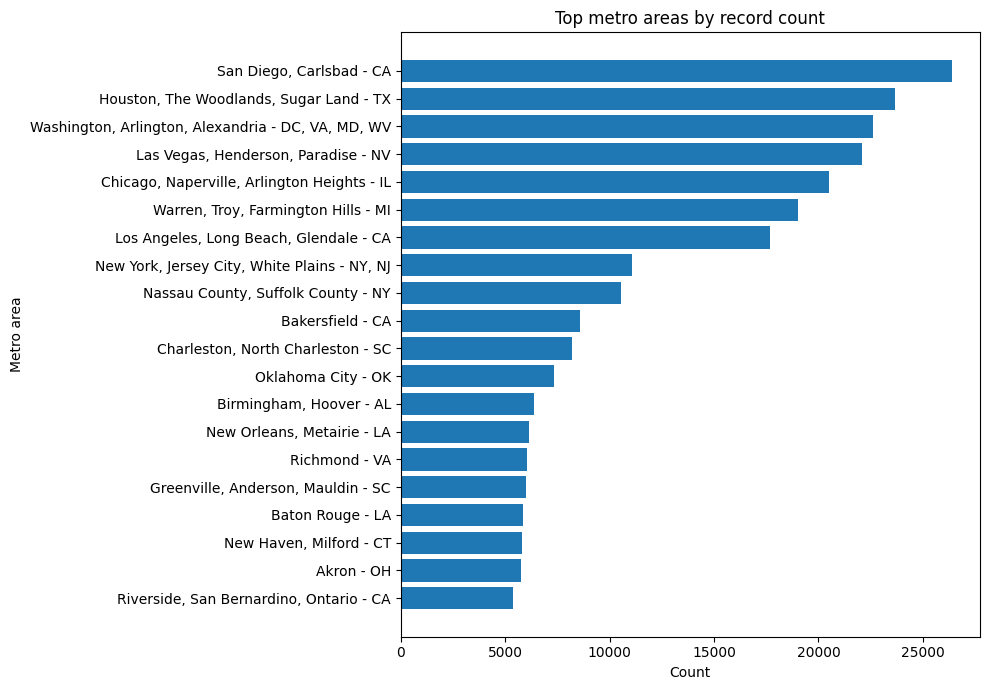

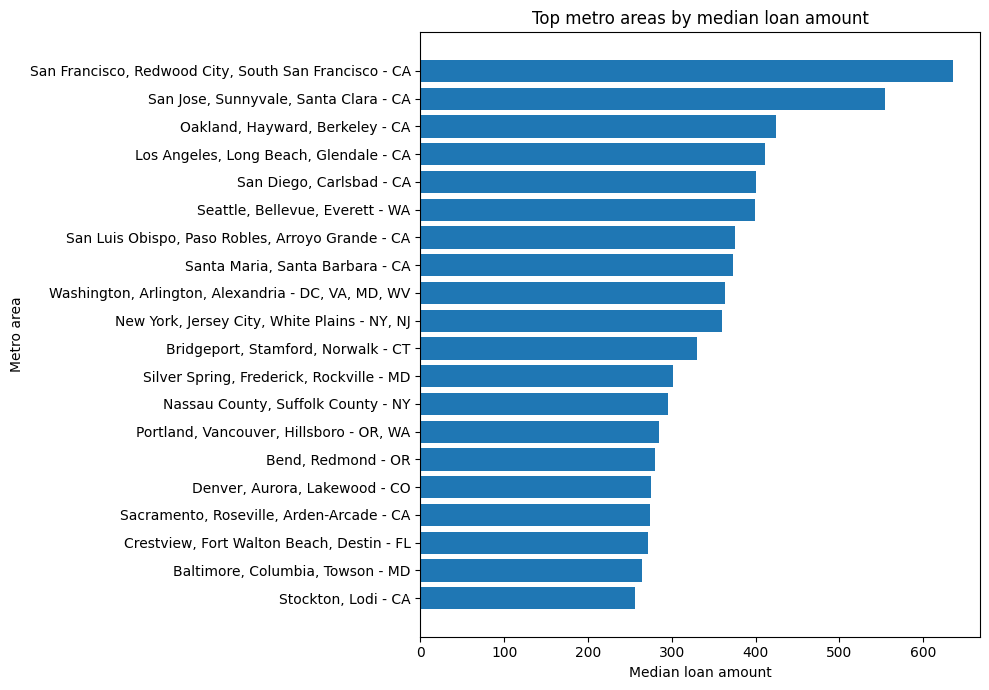

In [19]:
if "msamd_name" in df.columns:
    msamd_summary = (
        df
        .groupby("msamd_name")
        .agg(
            count=(TARGET_COL, "size"),
            median_loan_amount=(TARGET_COL, "median"),
            mean_loan_amount=(TARGET_COL, "mean")
        )
        .reset_index()
        .sort_values("count", ascending=False)
    )
    
    display(msamd_summary.head(20))
    
    top_msamd = msamd_summary.head(20)
    
    plt.figure(figsize=(10, 7))
    plt.barh(top_msamd["msamd_name"], top_msamd["count"])
    plt.gca().invert_yaxis()
    plt.title("Top metro areas by record count")
    plt.xlabel("Count")
    plt.ylabel("Metro area")
    plt.tight_layout()
    plt.show()
    
    top_msamd_by_median = msamd_summary[msamd_summary["count"] >= 300].sort_values(
        "median_loan_amount",
        ascending=False
    ).head(20)
    
    plt.figure(figsize=(10, 7))
    plt.barh(top_msamd_by_median["msamd_name"], top_msamd_by_median["median_loan_amount"])
    plt.gca().invert_yaxis()
    plt.title("Top metro areas by median loan amount")
    plt.xlabel("Median loan amount")
    plt.ylabel("Metro area")
    plt.tight_layout()
    plt.show()

# High cardinality columns

Some columns have many unique values.

These columns may need special encoding later.

We do not encode them now.

In [20]:
high_cardinality_summary = []

for col in high_cardinality_cols:
    high_cardinality_summary.append({
        "column": col,
        "unique_count": df[col].nunique(dropna=False),
        "top_value": df[col].value_counts(dropna=False).index[0],
        "top_value_count": df[col].value_counts(dropna=False).iloc[0]
    })

high_cardinality_summary = pd.DataFrame(high_cardinality_summary)

display(high_cardinality_summary)

,column,unique_count,top_value,top_value_count
0,respondent_id,4278,7197000003,32483
1,county_name,884,San Diego County,26416
2,msamd_name,409,"San Diego, Carlsbad - CA",26416
3,census_tract_number,18321,20.0,1164


# Sensitive feature analysis

These features are sensitive.

We use them for audit and understanding.

We do not make causal claims from these plots.

Sensitive feature: applicant_ethnicity_name


,applicant_ethnicity_name,count,mean_loan_amount,median_loan_amount,percent
2,Not Hispanic or Latino,373235,247.466776,199.0,74.69
1,"Information not provided by applicant in mail,...",71669,274.839694,208.0,14.34
0,Hispanic or Latino,54477,208.530040,177.0,10.90
3,Not applicable,355,299.940845,223.0,0.07


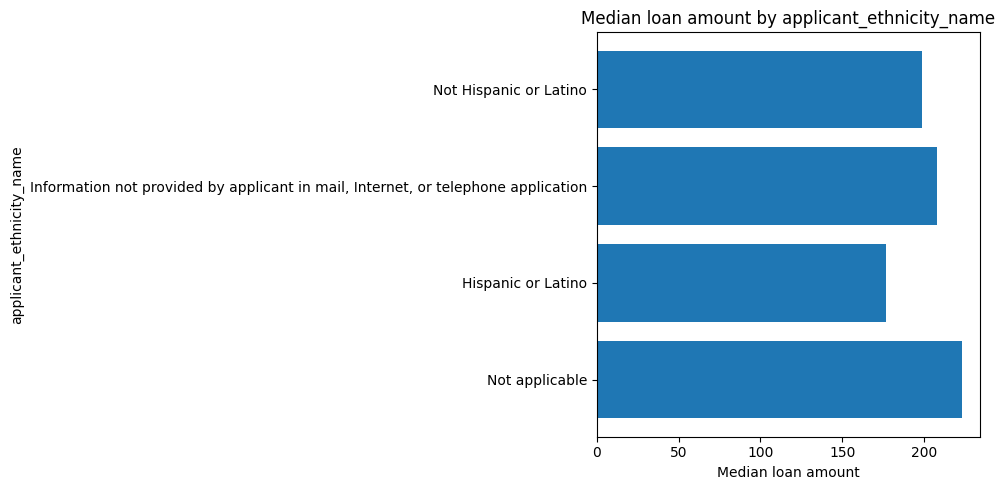

Sensitive feature: co_applicant_ethnicity_name


,co_applicant_ethnicity_name,count,mean_loan_amount,median_loan_amount,percent
2,No co-applicant,276767,219.901047,176.0,55.38
3,Not Hispanic or Latino,163755,280.877653,228.0,32.77
1,"Information not provided by applicant in mail,...",36597,306.896385,238.0,7.32
0,Hispanic or Latino,22278,239.263489,208.0,4.46
4,Not applicable,339,321.669617,231.0,0.07


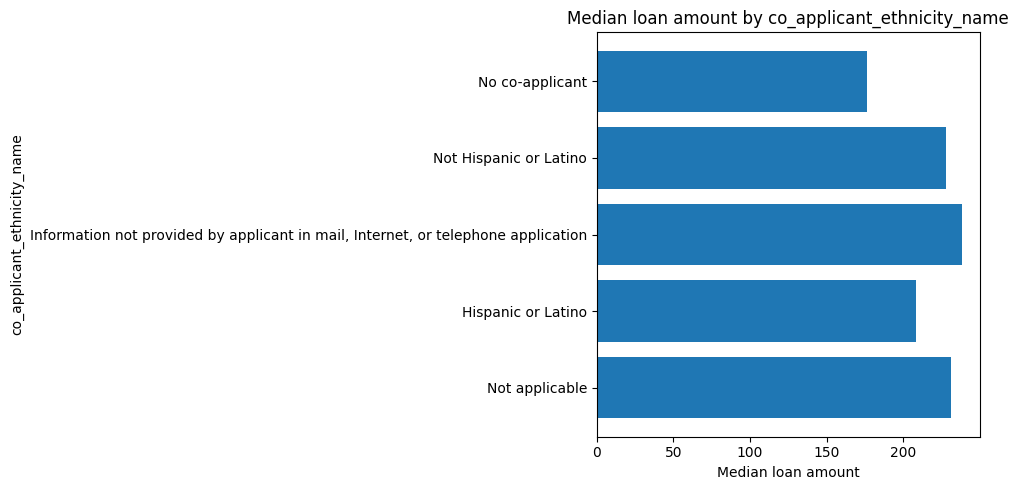

Sensitive feature: applicant_race_name_1


,applicant_race_name_1,count,mean_loan_amount,median_loan_amount,percent
6,White,352834,239.013482,192.0,70.60
3,"Information not provided by applicant in mail,...",76364,273.273755,210.0,15.28
2,Black or African American,35820,197.276131,171.0,7.17
1,Asian,28673,344.161720,289.0,5.74
0,American Indian or Alaska Native,3489,198.781886,168.0,0.70
4,Native Hawaiian or Other Pacific Islander,2388,266.131072,230.5,0.48
5,Not applicable,168,376.827381,247.0,0.03


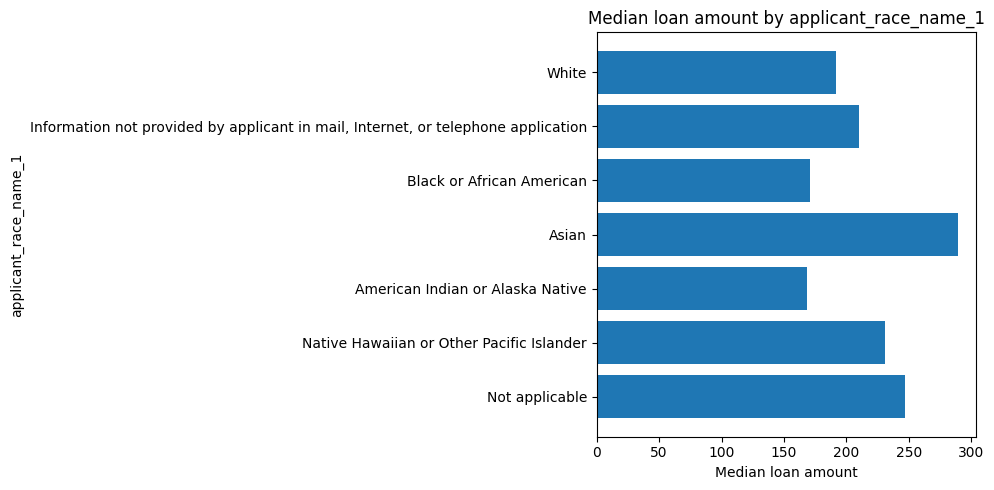

Sensitive feature: co_applicant_race_name_1


,co_applicant_race_name_1,count,mean_loan_amount,median_loan_amount,percent
5,No co-applicant,276767,219.901047,176.0,55.38
7,White,159116,268.640558,220.0,31.84
3,"Information not provided by applicant in mail,...",38537,306.308068,240.0,7.71
1,Asian,12940,388.552705,320.0,2.59
2,Black or African American,9309,241.781072,213.0,1.86
4,Native Hawaiian or Other Pacific Islander,1555,292.652090,261.0,0.31
0,American Indian or Alaska Native,1283,229.187841,192.0,0.26
6,Not applicable,229,388.759825,260.0,0.05


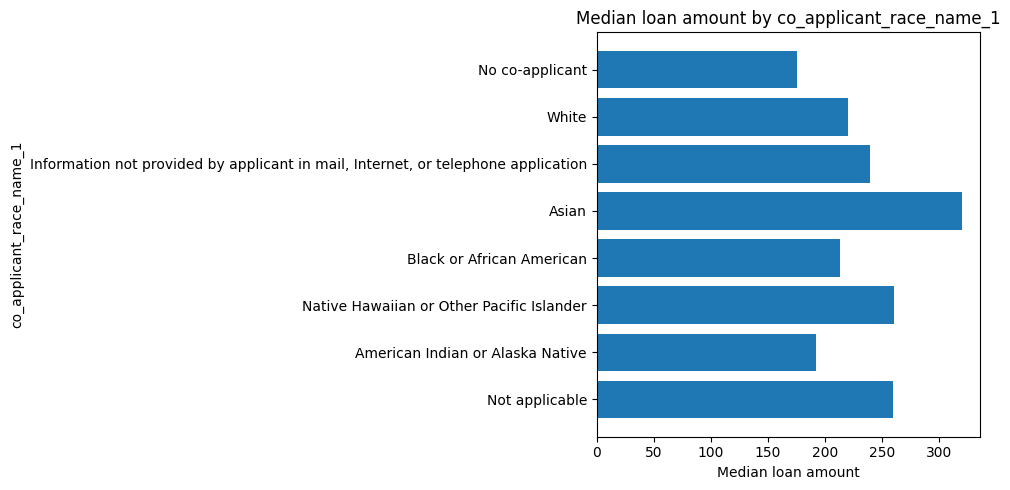

Sensitive feature: applicant_sex_name


,applicant_sex_name,count,mean_loan_amount,median_loan_amount,percent
2,Male,311026,260.150052,208.0,62.24
0,Female,142849,210.321535,173.0,28.58
1,"Information not provided by applicant in mail,...",45714,273.801439,203.0,9.15
3,Not applicable,147,361.278912,182.0,0.03


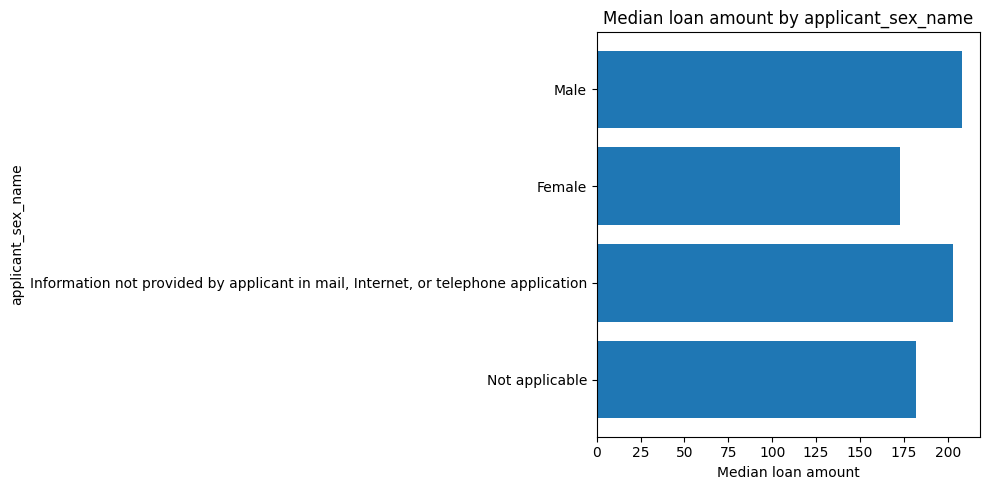

Sensitive feature: co_applicant_sex_name


,co_applicant_sex_name,count,mean_loan_amount,median_loan_amount,percent
3,No co-applicant,276767,219.901047,176.0,55.38
0,Female,156008,284.915652,231.0,31.22
2,Male,43275,253.798567,210.0,8.66
1,"Information not provided by applicant in mail,...",23466,304.635473,233.0,4.70
4,Not applicable,220,386.977273,251.5,0.04


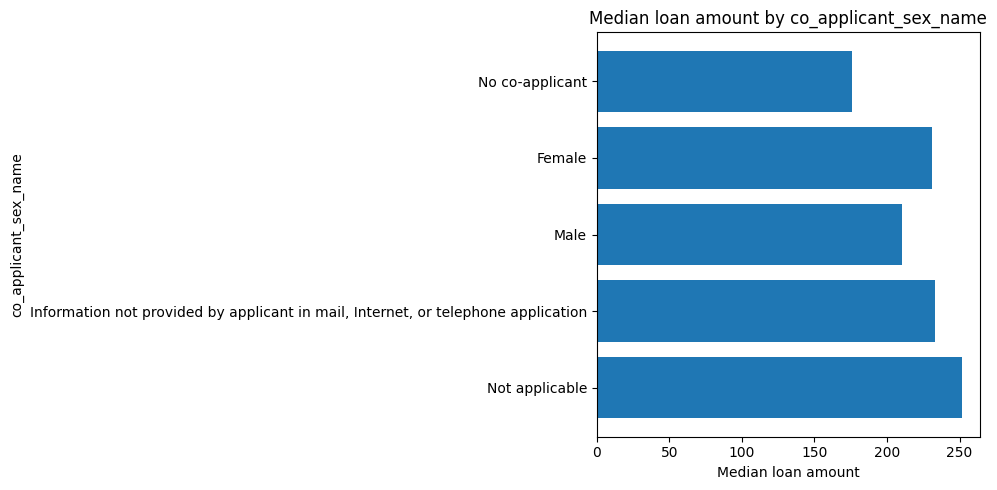

In [21]:
sensitive_categorical_cols = [
    col for col in sensitive_cols
    if col != "minority_population"
]

for col in sensitive_categorical_cols:
    print("=" * 100)
    print("Sensitive feature:", col)
    
    summary = categorical_target_summary(df, col, TARGET_COL, top_n=15)
    display(summary)
    
    plt.figure(figsize=(10, 5))
    plt.barh(summary[col].astype(str), summary["median_loan_amount"])
    plt.gca().invert_yaxis()
    plt.title(f"Median loan amount by {col}")
    plt.xlabel("Median loan amount")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

,minority_population_bin,loan_amount_000s
0,"(-0.001, 6.7]",167.0
1,"(6.7, 11.21]",187.0
2,"(11.21, 15.75]",200.0
3,"(15.75, 20.79]",200.0
4,"(20.79, 26.62]",207.0
5,"(26.62, 33.69]",206.0
6,"(33.69, 42.42]",209.0
7,"(42.42, 54.8]",213.0
8,"(54.8, 75.32]",207.0
9,"(75.32, 100.0]",170.0


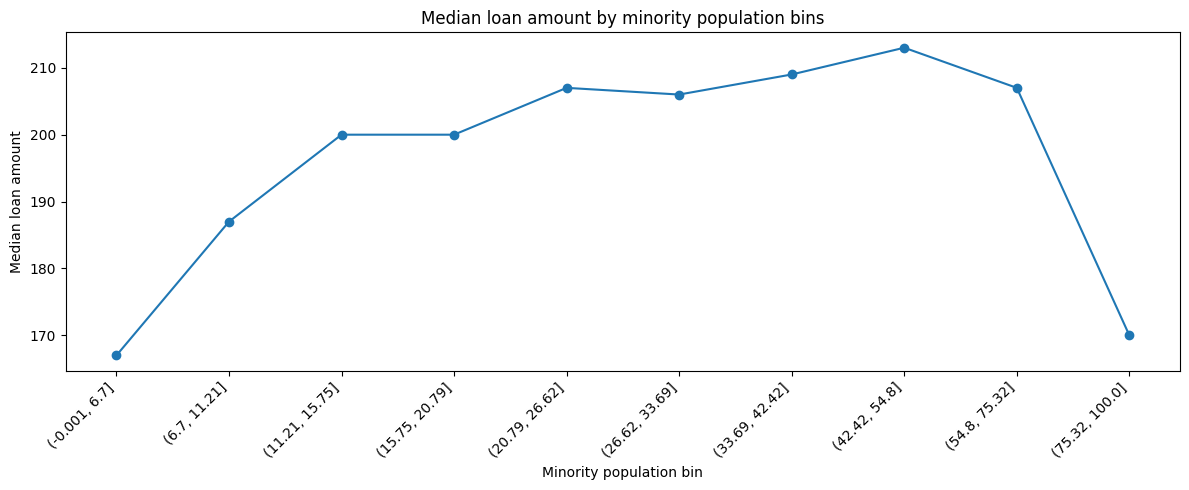

In [22]:
if "minority_population" in df.columns:
    temp = df[["minority_population", TARGET_COL]].copy()
    temp["minority_population"] = pd.to_numeric(temp["minority_population"], errors="coerce")
    temp[TARGET_COL] = pd.to_numeric(temp[TARGET_COL], errors="coerce")
    temp = temp.dropna()
    
    temp["minority_population_bin"] = pd.qcut(
        temp["minority_population"],
        q=10,
        duplicates="drop"
    )
    
    minority_summary = (
        temp
        .groupby("minority_population_bin", observed=False)[TARGET_COL]
        .median()
        .reset_index()
    )
    
    minority_summary["minority_population_bin"] = minority_summary["minority_population_bin"].astype(str)
    
    display(minority_summary)
    
    plt.figure(figsize=(12, 5))
    plt.plot(
        minority_summary["minority_population_bin"],
        minority_summary[TARGET_COL],
        marker="o"
    )
    plt.xticks(rotation=45, ha="right")
    plt.title("Median loan amount by minority population bins")
    plt.xlabel("Minority population bin")
    plt.ylabel("Median loan amount")
    plt.tight_layout()
    plt.show()

In [23]:
base_feature_plan = pd.DataFrame({
    "group": [
        "target",
        "numeric_features",
        "categorical_features",
        "sensitive_features",
        "high_cardinality_features",
        "columns_not_for_model_input"
    ],
    "columns": [
        [TARGET_COL],
        numeric_feature_cols,
        categorical_cols,
        sensitive_cols,
        high_cardinality_cols,
        [TARGET_COL, CLASS_TARGET_COL]
    ]
})

display(base_feature_plan)

,group,columns
0,target,[loan_amount_000s]
1,numeric_features,"[applicant_income_000s, population, minority_p..."
2,categorical_features,"[agency_name, loan_type_name, property_type_na..."
3,sensitive_features,"[applicant_ethnicity_name, co_applicant_ethnic..."
4,high_cardinality_features,"[respondent_id, county_name, msamd_name, censu..."
5,columns_not_for_model_input,"[loan_amount_000s, loan_approved]"


# Universal feature engineering

We now create general features.

These features are useful for most regression models.

We do not apply scaling here.

We do not apply encoding here.

Model specific preprocessing will be done later.

In [24]:
# Work on a copy so the original dataframe stays unchanged
df_fe = df.copy(deep=True)

# Convert numeric columns inside the feature engineering copy
for col in numeric_cols:
    if col in df_fe.columns:
        df_fe[col] = pd.to_numeric(df_fe[col], errors="coerce")

print("Original df shape:", df.shape)
print("Feature engineering copy shape:", df_fe.shape)

Original df shape: (499736, 30)
Feature engineering copy shape: (499736, 30)


# Helper columns for plots

Loan amount and income are stored in thousands of dollars.

We create dollar versions only for EDA.

These columns are not model features.

In [25]:
df_fe["loan_amount_dollars_for_eda"] = df_fe["loan_amount_000s"] * 1000
df_fe["applicant_income_dollars_for_eda"] = df_fe["applicant_income_000s"] * 1000

print("EDA dollar columns created.")

EDA dollar columns created.


# Create general domain features

These features use income.

They use neighborhood income.

They use housing structure.

They also use loan type and location.

Each feature is created without using the target as input.

In [26]:
def safe_divide(a, b):
    result = a / b
    return result.replace([np.inf, -np.inf], np.nan)


# This target transform can be used as y later.
# It is not a model input feature.
df_fe["log1p_loan_amount_target"] = np.log1p(df_fe["loan_amount_000s"])


# This feature reduces income skew.
# Higher values mean higher applicant income.
df_fe["log1p_applicant_income"] = np.log1p(df_fe["applicant_income_000s"])


# This feature reduces population skew.
# Population can be very different across tracts.
df_fe["log1p_population"] = np.log1p(df_fe["population"])


# This feature reduces area income skew.
# It keeps the area income signal in a smoother scale.
df_fe["log1p_hud_median_family_income"] = np.log1p(df_fe["hud_median_family_income"])


# This feature reduces housing unit skew.
# It describes the size of the owner occupied housing market.
df_fe["log1p_owner_occupied_units"] = np.log1p(df_fe["number_of_owner_occupied_units"])


# This feature reduces housing unit skew.
# It describes the amount of small family housing units.
df_fe["log1p_1_to_4_family_units"] = np.log1p(df_fe["number_of_1_to_4_family_units"])


# This feature compares applicant income with area median family income.
# It helps show if the applicant is high income for that area.
df_fe["applicant_income_to_area_income"] = safe_divide(
    df_fe["applicant_income_000s"],
    df_fe["hud_median_family_income"] / 1000
)


# This feature converts tract income percent into a ratio.
# A value above 1 means the tract is richer than the metro area.
df_fe["tract_income_ratio"] = df_fe["tract_to_msamd_income"] / 100


# This feature shows the share of small family units that are owner occupied.
# It describes the home ownership structure of the tract.
df_fe["owner_occupied_unit_ratio"] = safe_divide(
    df_fe["number_of_owner_occupied_units"],
    df_fe["number_of_1_to_4_family_units"]
)


# This feature shows small family housing density.
# It is measured per 1000 people.
df_fe["family_units_per_1000_people"] = safe_divide(
    df_fe["number_of_1_to_4_family_units"],
    df_fe["population"]
) * 1000


# This feature shows owner occupied unit density.
# It is measured per 1000 people.
df_fe["owner_occupied_units_per_1000_people"] = safe_divide(
    df_fe["number_of_owner_occupied_units"],
    df_fe["population"]
) * 1000


# This feature checks if there is a co applicant.
# Joint applications may support larger loan amounts.
if "co_applicant_sex_name" in df_fe.columns:
    df_fe["has_co_applicant"] = (
        ~df_fe["co_applicant_sex_name"]
        .astype(str)
        .str.contains("No co-applicant", case=False, na=False)
    ).astype(int)


# This feature groups loan programs.
# Government backed loans can behave differently from conventional loans.
if "loan_type_name" in df_fe.columns:
    df_fe["loan_program_group"] = np.where(
        df_fe["loan_type_name"].astype(str).str.contains("FHA|VA|FSA|RHS", case=False, na=False),
        "Government backed",
        "Conventional"
    )


# This feature groups applicants by income relative to area income.
# Cutoffs follow common low and moderate income analysis.
df_fe["applicant_income_area_group"] = pd.cut(
    df_fe["applicant_income_to_area_income"],
    bins=[-np.inf, 0.5, 0.8, 1.2, np.inf],
    labels=["Very low", "Low", "Moderate", "High"]
).astype(str)


# This feature groups tracts by income relative to the metro area.
# It gives a simple neighborhood income level.
df_fe["tract_income_level"] = pd.cut(
    df_fe["tract_income_ratio"],
    bins=[-np.inf, 0.5, 0.8, 1.2, np.inf],
    labels=["Very low", "Low", "Moderate", "High"]
).astype(str)


# This audit feature checks if minority population is at least 50 percent.
# It should be used with care in fairness analysis.
df_fe["majority_minority_tract"] = np.where(
    df_fe["minority_population"] >= 50,
    "Majority minority",
    "Not majority minority"
)

# Add a broad region feature

State is detailed.

A region feature gives a wider location view.

This can help simple analysis.

In [27]:
state_to_region = {
    "Connecticut": "Northeast",
    "Maine": "Northeast",
    "Massachusetts": "Northeast",
    "New Hampshire": "Northeast",
    "Rhode Island": "Northeast",
    "Vermont": "Northeast",
    "New Jersey": "Northeast",
    "New York": "Northeast",
    "Pennsylvania": "Northeast",
    "Illinois": "Midwest",
    "Indiana": "Midwest",
    "Michigan": "Midwest",
    "Ohio": "Midwest",
    "Wisconsin": "Midwest",
    "Iowa": "Midwest",
    "Kansas": "Midwest",
    "Minnesota": "Midwest",
    "Missouri": "Midwest",
    "Nebraska": "Midwest",
    "North Dakota": "Midwest",
    "South Dakota": "Midwest",
    "Delaware": "South",
    "District of Columbia": "South",
    "Florida": "South",
    "Georgia": "South",
    "Maryland": "South",
    "North Carolina": "South",
    "South Carolina": "South",
    "Virginia": "South",
    "West Virginia": "South",
    "Alabama": "South",
    "Kentucky": "South",
    "Mississippi": "South",
    "Tennessee": "South",
    "Arkansas": "South",
    "Louisiana": "South",
    "Oklahoma": "South",
    "Texas": "South",
    "Arizona": "West",
    "Colorado": "West",
    "Idaho": "West",
    "Montana": "West",
    "Nevada": "West",
    "New Mexico": "West",
    "Utah": "West",
    "Wyoming": "West",
    "Alaska": "West",
    "California": "West",
    "Hawaii": "West",
    "Oregon": "West",
    "Washington": "West",
    "Puerto Rico": "Other"
}

# This feature maps state names into broad US regions.
# It reduces location detail for simple plots and simple models.
if "state_name" in df_fe.columns:
    df_fe["us_region"] = df_fe["state_name"].map(state_to_region).fillna("Other")

print("Feature engineering data shape:", df_fe.shape)

Feature engineering data shape: (499736, 49)


# Feature summary

This table explains the new features.

It also shows if the feature can be used as a model input.

Target based columns are not model inputs.

In [28]:
engineered_feature_summary = pd.DataFrame([
    {
        "feature": "log1p_loan_amount_target",
        "type": "target transform",
        "reason": "Reduces target skew",
        "use_as_model_input": "No"
    },
    {
        "feature": "log1p_applicant_income",
        "type": "numeric",
        "reason": "Reduces income skew",
        "use_as_model_input": "Yes"
    },
    {
        "feature": "log1p_population",
        "type": "numeric",
        "reason": "Reduces tract population skew",
        "use_as_model_input": "Yes"
    },
    {
        "feature": "log1p_hud_median_family_income",
        "type": "numeric",
        "reason": "Smooths area income",
        "use_as_model_input": "Yes"
    },
    {
        "feature": "log1p_owner_occupied_units",
        "type": "numeric",
        "reason": "Smooths owner occupied unit count",
        "use_as_model_input": "Yes"
    },
    {
        "feature": "log1p_1_to_4_family_units",
        "type": "numeric",
        "reason": "Smooths small family unit count",
        "use_as_model_input": "Yes"
    },
    {
        "feature": "applicant_income_to_area_income",
        "type": "ratio",
        "reason": "Compares applicant income with area income",
        "use_as_model_input": "Yes"
    },
    {
        "feature": "tract_income_ratio",
        "type": "ratio",
        "reason": "Shows tract income level relative to metro income",
        "use_as_model_input": "Yes"
    },
    {
        "feature": "owner_occupied_unit_ratio",
        "type": "ratio",
        "reason": "Shows ownership structure in the tract",
        "use_as_model_input": "Yes"
    },
    {
        "feature": "family_units_per_1000_people",
        "type": "density",
        "reason": "Shows small family housing density",
        "use_as_model_input": "Yes"
    },
    {
        "feature": "owner_occupied_units_per_1000_people",
        "type": "density",
        "reason": "Shows owner occupied housing density",
        "use_as_model_input": "Yes"
    },
    {
        "feature": "has_co_applicant",
        "type": "binary",
        "reason": "Shows if the application has a co applicant",
        "use_as_model_input": "Yes"
    },
    {
        "feature": "loan_program_group",
        "type": "categorical",
        "reason": "Groups conventional and government backed loans",
        "use_as_model_input": "Yes"
    },
    {
        "feature": "applicant_income_area_group",
        "type": "categorical",
        "reason": "Groups applicant income relative to area income",
        "use_as_model_input": "Yes"
    },
    {
        "feature": "tract_income_level",
        "type": "categorical",
        "reason": "Groups neighborhood income level",
        "use_as_model_input": "Yes"
    },
    {
        "feature": "majority_minority_tract",
        "type": "audit categorical",
        "reason": "Supports fairness audit",
        "use_as_model_input": "Audit only"
    },
    {
        "feature": "us_region",
        "type": "categorical",
        "reason": "Gives a broad location group",
        "use_as_model_input": "Yes"
    }
])

display(engineered_feature_summary)

,feature,type,reason,use_as_model_input
0,log1p_loan_amount_target,target transform,Reduces target skew,No
1,log1p_applicant_income,numeric,Reduces income skew,Yes
2,log1p_population,numeric,Reduces tract population skew,Yes
3,log1p_hud_median_family_income,numeric,Smooths area income,Yes
4,log1p_owner_occupied_units,numeric,Smooths owner occupied unit count,Yes
5,log1p_1_to_4_family_units,numeric,Smooths small family unit count,Yes
6,applicant_income_to_area_income,ratio,Compares applicant income with area income,Yes
7,tract_income_ratio,ratio,Shows tract income level relative to metro income,Yes
8,owner_occupied_unit_ratio,ratio,Shows ownership structure in the tract,Yes
9,family_units_per_1000_people,density,Shows small family housing density,Yes


# Visual check for log features

Log features help with skewed values.

We compare raw and log values.

The original data is not changed.

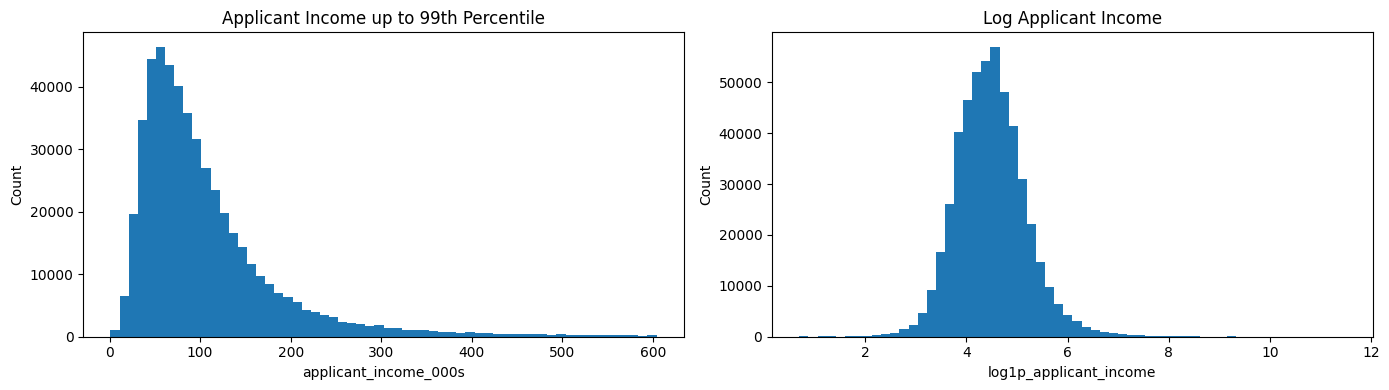

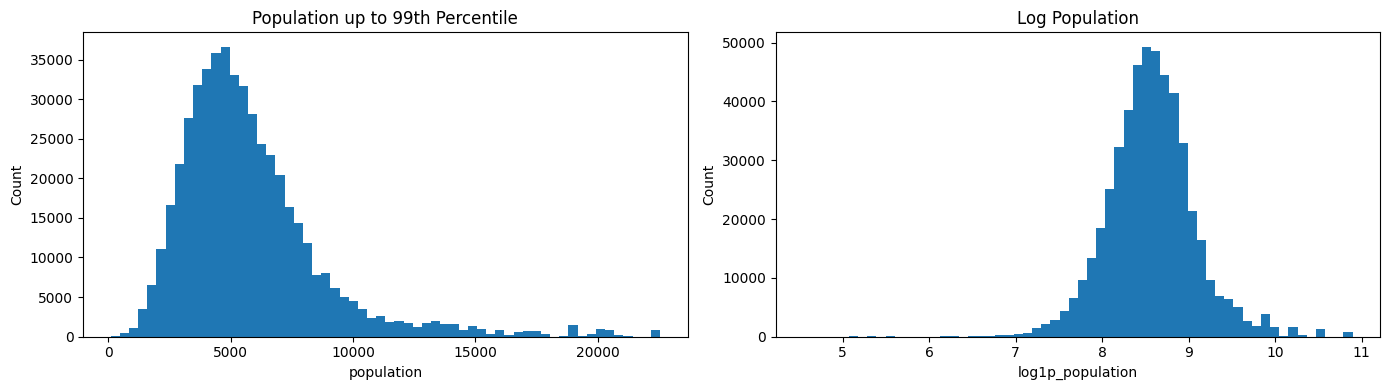

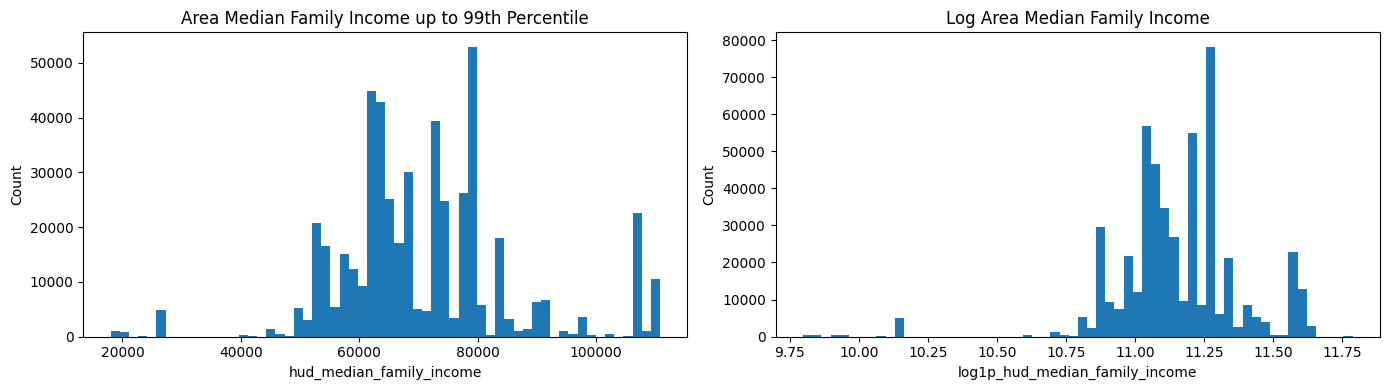

In [29]:
log_pairs = [
    ("applicant_income_000s", "log1p_applicant_income", "Applicant Income"),
    ("population", "log1p_population", "Population"),
    ("hud_median_family_income", "log1p_hud_median_family_income", "Area Median Family Income")
]

for raw_col, log_col, title in log_pairs:
    if raw_col in df_fe.columns and log_col in df_fe.columns:
        raw_values = df_fe[raw_col].dropna()
        log_values = df_fe[log_col].dropna()
        raw_limit = raw_values.quantile(0.99)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        axes[0].hist(raw_values[raw_values <= raw_limit], bins=60)
        axes[0].set_title(f"{title} up to 99th Percentile")
        axes[0].set_xlabel(raw_col)
        axes[0].set_ylabel("Count")
        
        axes[1].hist(log_values, bins=60)
        axes[1].set_title(f"Log {title}")
        axes[1].set_xlabel(log_col)
        axes[1].set_ylabel("Count")
        
        plt.tight_layout()
        plt.show()

# Applicant income relative to area income

This feature compares the applicant income with the area median income.

It gives a local income view.

This can be stronger than raw income alone.

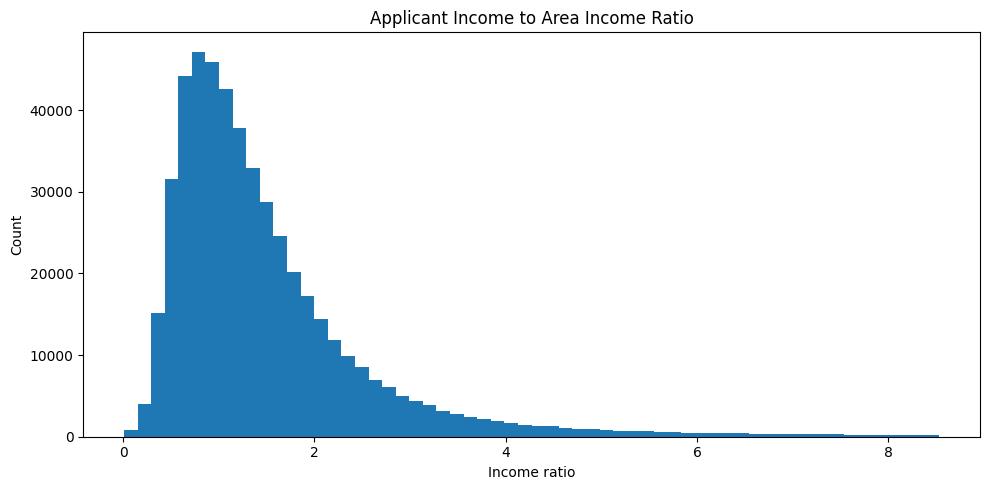

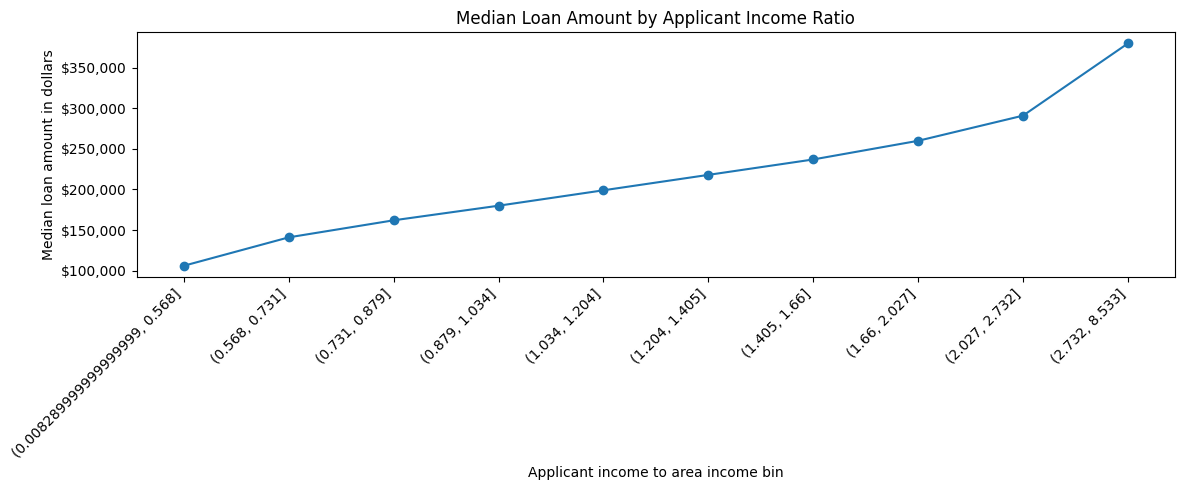

,ratio_bin,loan_amount_dollars_for_eda
0,"(0.008289999999999999, 0.568]",106000.0
1,"(0.568, 0.731]",141000.0
2,"(0.731, 0.879]",162000.0
3,"(0.879, 1.034]",180000.0
4,"(1.034, 1.204]",199000.0
5,"(1.204, 1.405]",218000.0
6,"(1.405, 1.66]",237000.0
7,"(1.66, 2.027]",260000.0
8,"(2.027, 2.732]",291000.0
9,"(2.732, 8.533]",380000.0


In [30]:
import matplotlib.ticker as ticker

ratio_col = "applicant_income_to_area_income"

if ratio_col in df_fe.columns:
    ratio_values = df_fe[ratio_col].dropna()
    ratio_limit = ratio_values.quantile(0.99)
    
    plt.figure(figsize=(10, 5))
    plt.hist(ratio_values[ratio_values <= ratio_limit], bins=60)
    plt.title("Applicant Income to Area Income Ratio")
    plt.xlabel("Income ratio")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
    
    temp = df_fe[[ratio_col, "loan_amount_dollars_for_eda"]].dropna().copy()
    temp = temp[temp[ratio_col] <= ratio_limit]
    temp["ratio_bin"] = pd.qcut(temp[ratio_col], q=10, duplicates="drop")
    
    ratio_summary = (
        temp
        .groupby("ratio_bin", observed=False)["loan_amount_dollars_for_eda"]
        .median()
        .reset_index()
    )
    
    ratio_summary["ratio_bin"] = ratio_summary["ratio_bin"].astype(str)
    
    plt.figure(figsize=(12, 5))
    plt.plot(
        ratio_summary["ratio_bin"],
        ratio_summary["loan_amount_dollars_for_eda"],
        marker="o"
    )
    plt.xticks(rotation=45, ha="right")
    plt.title("Median Loan Amount by Applicant Income Ratio")
    plt.xlabel("Applicant income to area income bin")
    plt.ylabel("Median loan amount in dollars")
    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
    )
    plt.tight_layout()
    plt.show()
    
    display(ratio_summary)

# Income groups

We group applicant income relative to area income.

We also group tract income relative to metro income.

These groups make the income signal easier to read.

,applicant_income_area_group,count,median_loan_amount
3,Very low,32360,98000.0
1,Low,90522,141000.0
2,Moderate,123592,183000.0
0,High,253262,265000.0


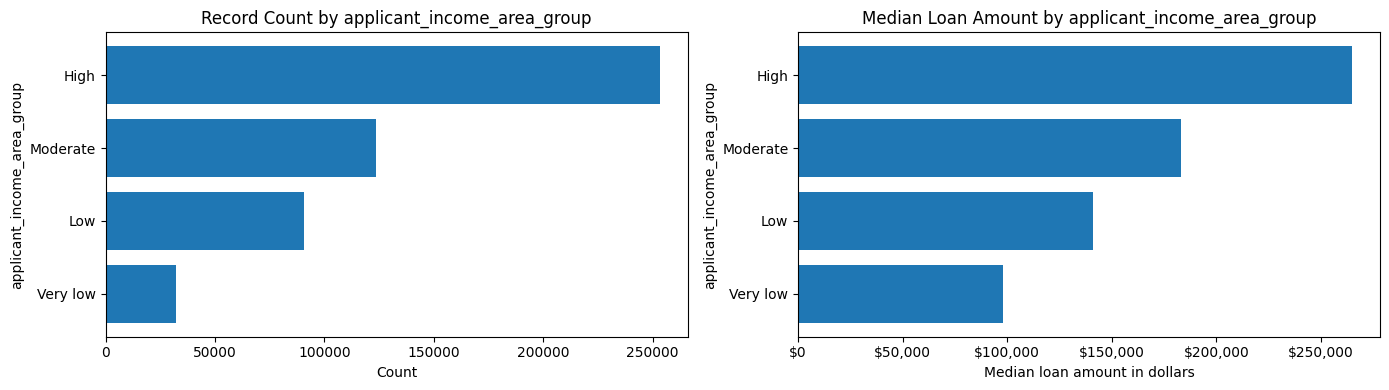

,tract_income_level,count,median_loan_amount
3,Very low,10099,134000.0
1,Low,68442,141000.0
2,Moderate,209277,173000.0
0,High,211918,251000.0


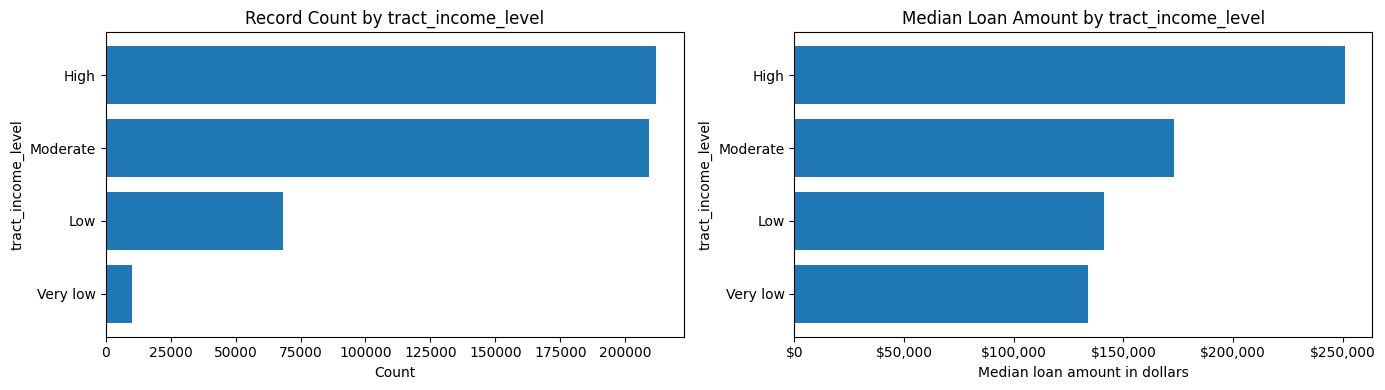

In [31]:
group_features = [
    "applicant_income_area_group",
    "tract_income_level"
]

for col in group_features:
    if col in df_fe.columns:
        temp = (
            df_fe
            .groupby(col)
            .agg(
                count=("loan_amount_dollars_for_eda", "size"),
                median_loan_amount=("loan_amount_dollars_for_eda", "median")
            )
            .reset_index()
            .sort_values("median_loan_amount", ascending=True)
        )
        
        display(temp)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        axes[0].barh(temp[col].astype(str), temp["count"])
        axes[0].set_title(f"Record Count by {col}")
        axes[0].set_xlabel("Count")
        axes[0].set_ylabel(col)
        
        axes[1].barh(temp[col].astype(str), temp["median_loan_amount"])
        axes[1].set_title(f"Median Loan Amount by {col}")
        axes[1].set_xlabel("Median loan amount in dollars")
        axes[1].set_ylabel(col)
        axes[1].xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
        )
        
        plt.tight_layout()
        plt.show()

# Housing structure features

These features describe the census tract.

They use owner occupied units.

They also use small family housing units.

They give a housing market context.

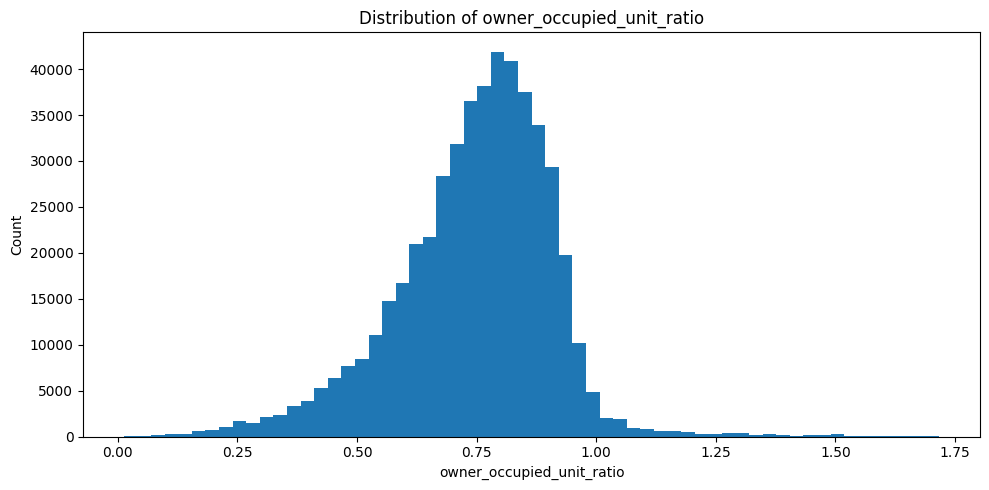

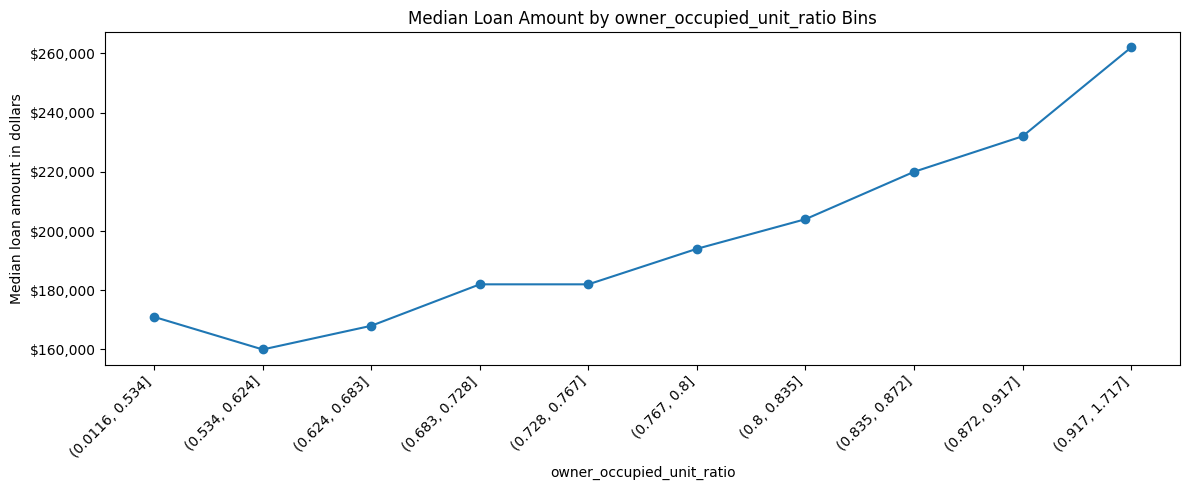

,feature_bin,loan_amount_dollars_for_eda
0,"(0.0116, 0.534]",171000.0
1,"(0.534, 0.624]",160000.0
2,"(0.624, 0.683]",168000.0
3,"(0.683, 0.728]",182000.0
4,"(0.728, 0.767]",182000.0
5,"(0.767, 0.8]",194000.0
6,"(0.8, 0.835]",204000.0
7,"(0.835, 0.872]",220000.0
8,"(0.872, 0.917]",232000.0
9,"(0.917, 1.717]",262000.0


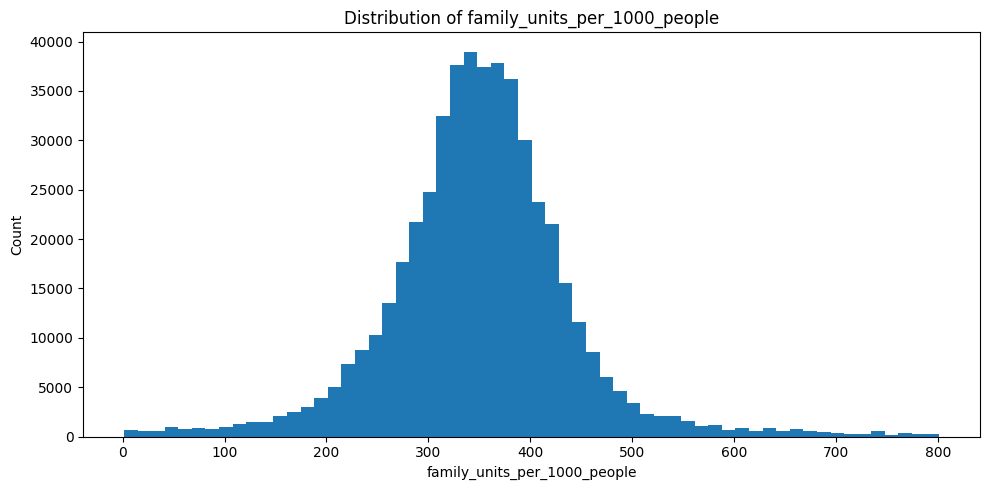

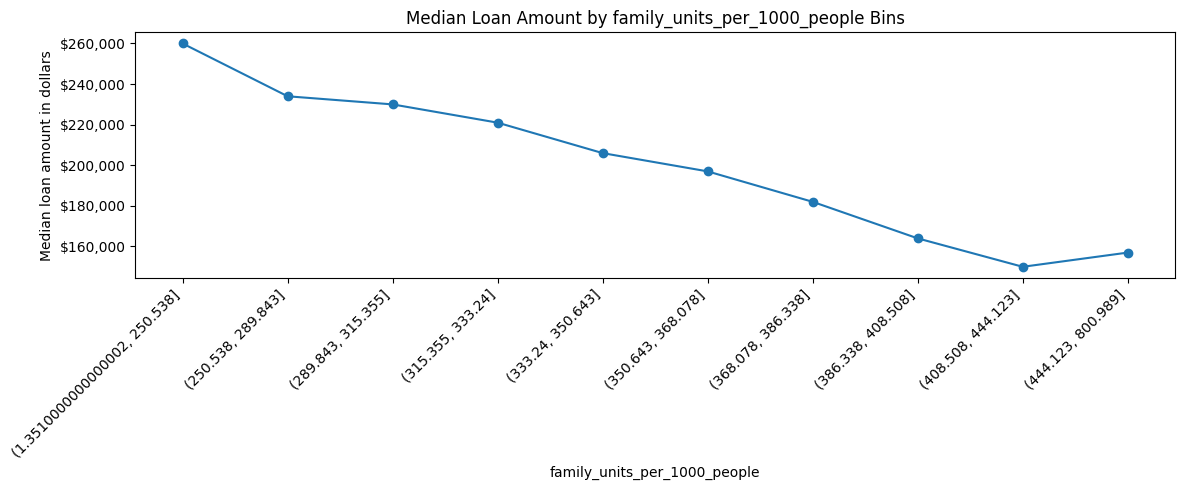

,feature_bin,loan_amount_dollars_for_eda
0,"(1.3510000000000002, 250.538]",260000.0
1,"(250.538, 289.843]",234000.0
2,"(289.843, 315.355]",230000.0
3,"(315.355, 333.24]",221000.0
4,"(333.24, 350.643]",206000.0
5,"(350.643, 368.078]",197000.0
6,"(368.078, 386.338]",182000.0
7,"(386.338, 408.508]",164000.0
8,"(408.508, 444.123]",150000.0
9,"(444.123, 800.989]",157000.0


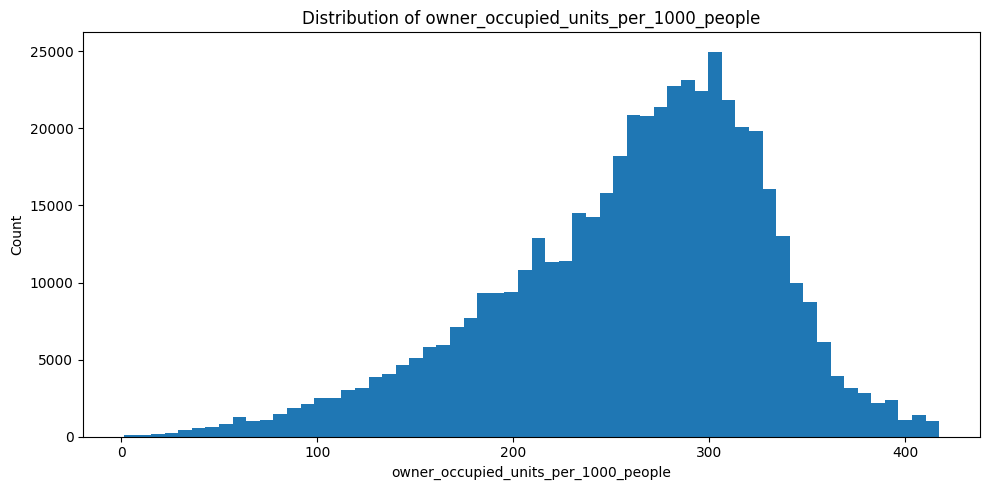

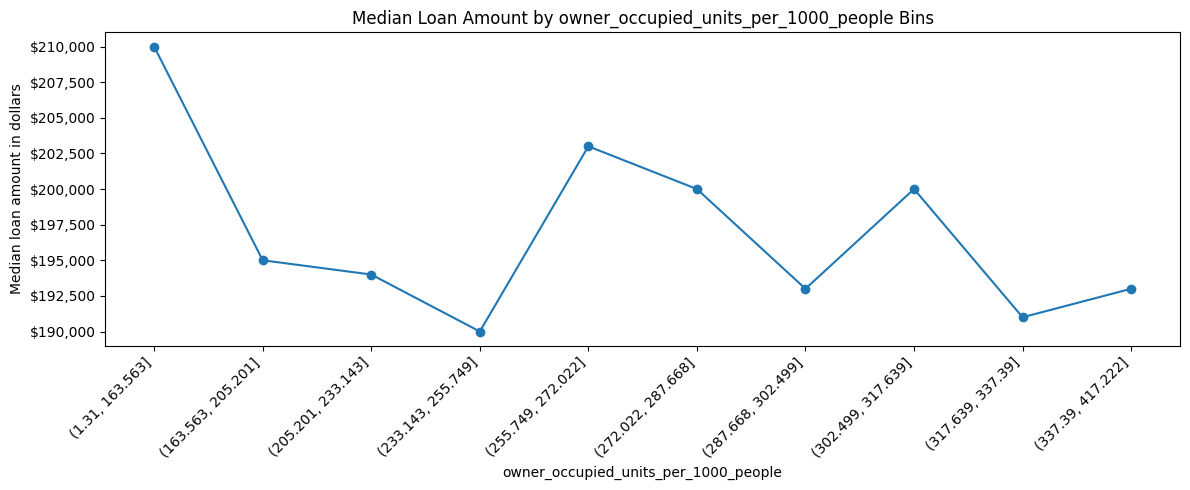

,feature_bin,loan_amount_dollars_for_eda
0,"(1.31, 163.563]",210000.0
1,"(163.563, 205.201]",195000.0
2,"(205.201, 233.143]",194000.0
3,"(233.143, 255.749]",190000.0
4,"(255.749, 272.022]",203000.0
5,"(272.022, 287.668]",200000.0
6,"(287.668, 302.499]",193000.0
7,"(302.499, 317.639]",200000.0
8,"(317.639, 337.39]",191000.0
9,"(337.39, 417.222]",193000.0


In [32]:
housing_numeric_features = [
    "owner_occupied_unit_ratio",
    "family_units_per_1000_people",
    "owner_occupied_units_per_1000_people"
]

for col in housing_numeric_features:
    if col in df_fe.columns:
        values = df_fe[col].dropna()
        upper = values.quantile(0.99)
        
        plt.figure(figsize=(10, 5))
        plt.hist(values[values <= upper], bins=60)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
        
        temp = df_fe[[col, "loan_amount_dollars_for_eda"]].dropna().copy()
        temp = temp[temp[col] <= upper]
        
        if temp[col].nunique() > 3:
            temp["feature_bin"] = pd.qcut(temp[col], q=10, duplicates="drop")
            
            summary = (
                temp
                .groupby("feature_bin", observed=False)["loan_amount_dollars_for_eda"]
                .median()
                .reset_index()
            )
            
            summary["feature_bin"] = summary["feature_bin"].astype(str)
            
            plt.figure(figsize=(12, 5))
            plt.plot(summary["feature_bin"], summary["loan_amount_dollars_for_eda"], marker="o")
            plt.xticks(rotation=45, ha="right")
            plt.title(f"Median Loan Amount by {col} Bins")
            plt.xlabel(col)
            plt.ylabel("Median loan amount in dollars")
            plt.gca().yaxis.set_major_formatter(
                ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
            )
            plt.tight_layout()
            plt.show()
            
            display(summary)

# Co applicant feature

A co applicant may increase borrowing capacity.

We compare loan amount for single and joint applications.

This feature is simple and useful.

,has_co_applicant,count,median_loan_amount,mean_loan_amount
0,No co applicant,276767,176000.0,219901.046729
1,Has co applicant,222969,227000.0,281052.366024


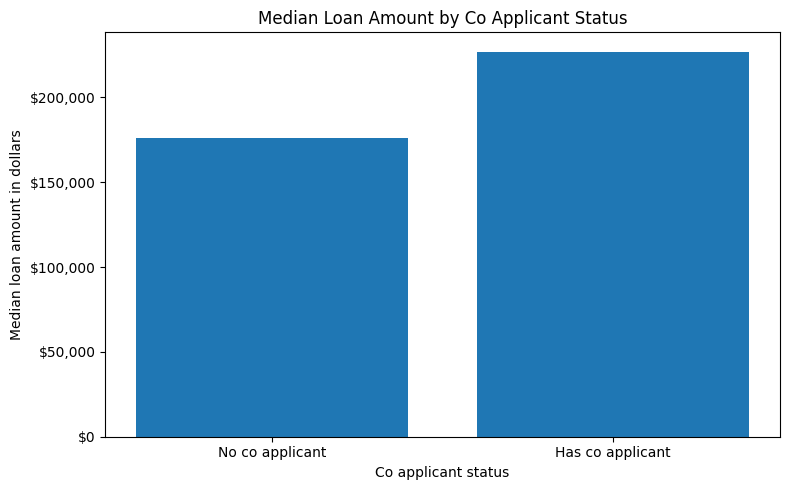

In [33]:
if "has_co_applicant" in df_fe.columns:
    co_summary = (
        df_fe
        .groupby("has_co_applicant")
        .agg(
            count=("loan_amount_dollars_for_eda", "size"),
            median_loan_amount=("loan_amount_dollars_for_eda", "median"),
            mean_loan_amount=("loan_amount_dollars_for_eda", "mean")
        )
        .reset_index()
    )
    
    co_summary["has_co_applicant"] = co_summary["has_co_applicant"].map({
        0: "No co applicant",
        1: "Has co applicant"
    })
    
    display(co_summary)
    
    plt.figure(figsize=(8, 5))
    plt.bar(co_summary["has_co_applicant"], co_summary["median_loan_amount"])
    plt.title("Median Loan Amount by Co Applicant Status")
    plt.xlabel("Co applicant status")
    plt.ylabel("Median loan amount in dollars")
    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
    )
    plt.tight_layout()
    plt.show()

# Loan program group

Government backed loans can have different patterns.

We compare them with conventional loans.

This feature simplifies loan type.

,loan_program_group,count,median_loan_amount,mean_loan_amount
1,Government backed,128935,196000.0,224106.829022
0,Conventional,370801,198000.0,255209.948193


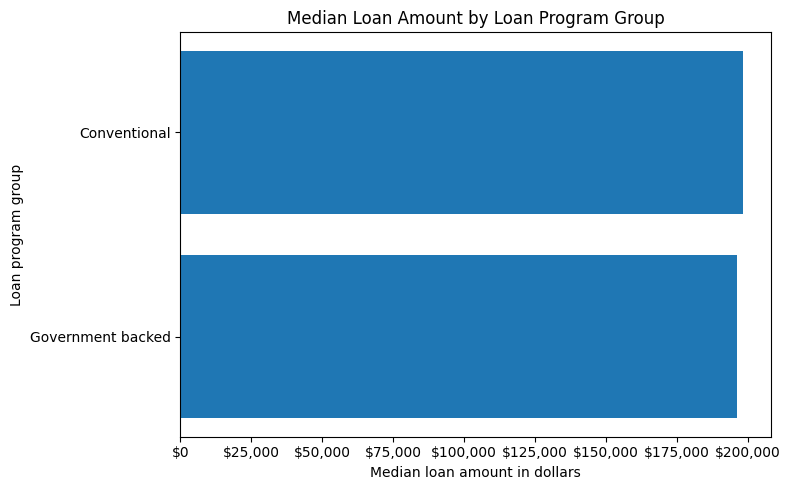

In [34]:
if "loan_program_group" in df_fe.columns:
    program_summary = (
        df_fe
        .groupby("loan_program_group")
        .agg(
            count=("loan_amount_dollars_for_eda", "size"),
            median_loan_amount=("loan_amount_dollars_for_eda", "median"),
            mean_loan_amount=("loan_amount_dollars_for_eda", "mean")
        )
        .reset_index()
        .sort_values("median_loan_amount", ascending=True)
    )
    
    display(program_summary)
    
    plt.figure(figsize=(8, 5))
    plt.barh(program_summary["loan_program_group"], program_summary["median_loan_amount"])
    plt.title("Median Loan Amount by Loan Program Group")
    plt.xlabel("Median loan amount in dollars")
    plt.ylabel("Loan program group")
    plt.gca().xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
    )
    plt.tight_layout()
    plt.show()

# Region feature

The region feature gives a broad location view.

It is less detailed than state.

It can help simple models and simple plots.

,us_region,count,median_loan_amount,mean_loan_amount
2,Other,6861,79000.0,87548.025069
0,Midwest,101646,158000.0,188460.972394
3,South,224114,182000.0,220076.880516
1,Northeast,53290,223000.0,280360.086320
4,West,113825,280000.0,347091.131122


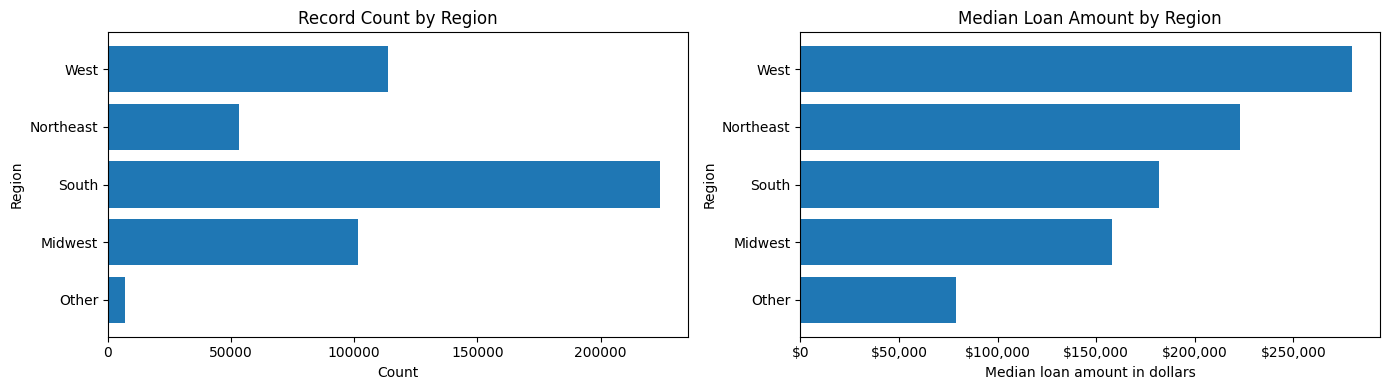

In [35]:
if "us_region" in df_fe.columns:
    region_summary = (
        df_fe
        .groupby("us_region")
        .agg(
            count=("loan_amount_dollars_for_eda", "size"),
            median_loan_amount=("loan_amount_dollars_for_eda", "median"),
            mean_loan_amount=("loan_amount_dollars_for_eda", "mean")
        )
        .reset_index()
        .sort_values("median_loan_amount", ascending=True)
    )
    
    display(region_summary)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    axes[0].barh(region_summary["us_region"], region_summary["count"])
    axes[0].set_title("Record Count by Region")
    axes[0].set_xlabel("Count")
    axes[0].set_ylabel("Region")
    
    axes[1].barh(region_summary["us_region"], region_summary["median_loan_amount"])
    axes[1].set_title("Median Loan Amount by Region")
    axes[1].set_xlabel("Median loan amount in dollars")
    axes[1].set_ylabel("Region")
    axes[1].xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
    )
    
    plt.tight_layout()
    plt.show()

# Majority minority tract audit feature

This feature is for audit.

It should be used with care.

It does not prove cause.

It only shows observed patterns.

,majority_minority_tract,count,median_loan_amount
0,Majority minority,116670,193000.0
1,Not majority minority,383066,199000.0


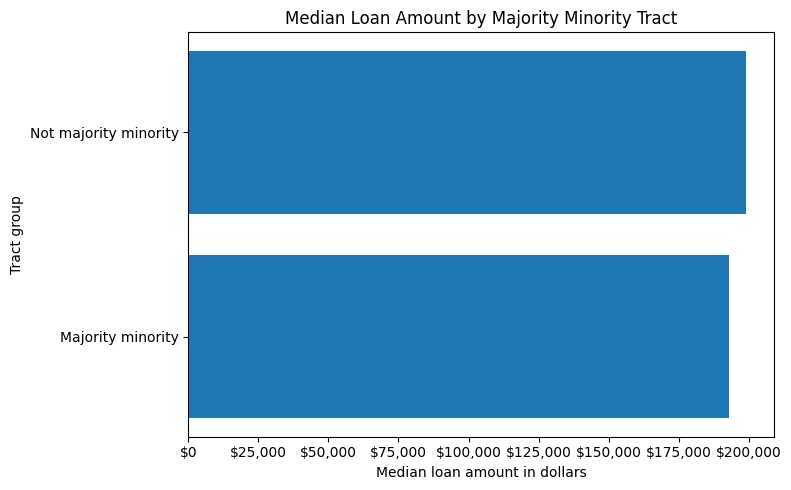

In [36]:
if "majority_minority_tract" in df_fe.columns:
    audit_summary = (
        df_fe
        .groupby("majority_minority_tract")
        .agg(
            count=("loan_amount_dollars_for_eda", "size"),
            median_loan_amount=("loan_amount_dollars_for_eda", "median")
        )
        .reset_index()
        .sort_values("median_loan_amount", ascending=True)
    )
    
    display(audit_summary)
    
    plt.figure(figsize=(8, 5))
    plt.barh(audit_summary["majority_minority_tract"], audit_summary["median_loan_amount"])
    plt.title("Median Loan Amount by Majority Minority Tract")
    plt.xlabel("Median loan amount in dollars")
    plt.ylabel("Tract group")
    plt.gca().xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
    )
    plt.tight_layout()
    plt.show()

# Updated feature groups

We now update the feature lists.

These lists help model building later.

No scaling is done here.

No encoding is done here.

In [37]:
engineered_numeric_features = [
    "log1p_applicant_income",
    "log1p_population",
    "log1p_hud_median_family_income",
    "log1p_owner_occupied_units",
    "log1p_1_to_4_family_units",
    "applicant_income_to_area_income",
    "tract_income_ratio",
    "owner_occupied_unit_ratio",
    "family_units_per_1000_people",
    "owner_occupied_units_per_1000_people"
]

engineered_numeric_features = [
    col for col in engineered_numeric_features
    if col in df_fe.columns
]

engineered_categorical_features = [
    "has_co_applicant",
    "loan_program_group",
    "applicant_income_area_group",
    "tract_income_level",
    "us_region"
]

engineered_categorical_features = [
    col for col in engineered_categorical_features
    if col in df_fe.columns
]

audit_only_features = [
    "majority_minority_tract"
]

audit_only_features = [
    col for col in audit_only_features
    if col in df_fe.columns
]

eda_only_cols = [
    "loan_amount_dollars_for_eda",
    "applicant_income_dollars_for_eda"
]

target_transform_cols = [
    "log1p_loan_amount_target",
    "log1p_loan_amount_for_eda"
]

excluded_model_input_cols = [
    TARGET_COL,
    CLASS_TARGET_COL
] + eda_only_cols + target_transform_cols

candidate_model_features = [
    col for col in df_fe.columns
    if col not in excluded_model_input_cols
]

protected_features_for_main_model = [
    "applicant_ethnicity_name",
    "co_applicant_ethnicity_name",
    "applicant_race_name_1",
    "co_applicant_race_name_1",
    "applicant_sex_name",
    "co_applicant_sex_name",
    "minority_population",
    "majority_minority_tract"
]

main_model_features = [
    col for col in candidate_model_features
    if col not in protected_features_for_main_model
]

feature_lists_summary = pd.DataFrame({
    "list_name": [
        "engineered_numeric_features",
        "engineered_categorical_features",
        "audit_only_features",
        "candidate_model_features",
        "main_model_features"
    ],
    "count": [
        len(engineered_numeric_features),
        len(engineered_categorical_features),
        len(audit_only_features),
        len(candidate_model_features),
        len(main_model_features)
    ],
    "columns": [
        engineered_numeric_features,
        engineered_categorical_features,
        audit_only_features,
        candidate_model_features,
        main_model_features
    ]
})

display(feature_lists_summary)

,list_name,count,columns
0,engineered_numeric_features,10,"[log1p_applicant_income, log1p_population, log..."
1,engineered_categorical_features,5,"[has_co_applicant, loan_program_group, applica..."
2,audit_only_features,1,[majority_minority_tract]
3,candidate_model_features,43,"[respondent_id, agency_name, loan_type_name, p..."
4,main_model_features,35,"[respondent_id, agency_name, loan_type_name, p..."


# Base modeling dataframe

We create a modeling copy.

This copy keeps the target.

It removes only EDA helper columns.

It does not encode features.

It does not scale features.

In [38]:
df_model_base = df_fe[
    [TARGET_COL] + candidate_model_features
].copy()

print("Feature engineering dataframe shape:", df_fe.shape)
print("Base modeling dataframe shape:", df_model_base.shape)

display(df_model_base.head())

Feature engineering dataframe shape: (499736, 49)
Base modeling dataframe shape: (499736, 44)


,loan_amount_000s,respondent_id,agency_name,loan_type_name,property_type_name,loan_purpose_name,owner_occupancy_name,preapproval_name,msamd_name,state_name,state_code,county_name,county_code,census_tract_number,applicant_ethnicity_name,co_applicant_ethnicity_name,applicant_race_name_1,co_applicant_race_name_1,applicant_sex_name,co_applicant_sex_name,applicant_income_000s,lien_status_name,population,minority_population,hud_median_family_income,tract_to_msamd_income,number_of_owner_occupied_units,number_of_1_to_4_family_units,log1p_applicant_income,log1p_population,log1p_hud_median_family_income,log1p_owner_occupied_units,log1p_1_to_4_family_units,applicant_income_to_area_income,tract_income_ratio,owner_occupied_unit_ratio,family_units_per_1000_people,owner_occupied_units_per_1000_people,has_co_applicant,loan_program_group,applicant_income_area_group,tract_income_level,majority_minority_tract,us_region
0,603,0000035295,Federal Deposit Insurance Corporation,Conventional,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,Not applicable,"Greenville, Anderson, Mauldin - SC",South Carolina,45,Greenville County,45,28.13,Not Hispanic or Latino,Not Hispanic or Latino,White,White,Male,Female,529,Secured by a first lien,4444,18.360001,57800,268.309998,1359,1457,6.272877,8.399535,10.964761,7.215240,7.284821,9.152249,2.6831,0.932739,327.857786,305.805581,1,Conventional,High,High,Not majority minority,South
1,341,33-0941669,Department of Housing and Urban Development,FHA-insured,One-to-four family dwelling (other than manufa...,Refinancing,Owner-occupied as a principal dwelling,Not applicable,"San Diego, Carlsbad - CA",California,6,San Diego County,73,85.04,"Information not provided by applicant in mail,...","Information not provided by applicant in mail,...",White,White,Male,Female,71,Secured by a first lien,5901,31.440001,79300,109.379997,1551,2276,4.276666,8.683047,11.281006,7.347300,7.730614,0.895334,1.0938,0.681459,385.697339,262.836807,1,Government backed,Moderate,Moderate,Not majority minority,West
2,215,7505400005,Department of Housing and Urban Development,VA-guaranteed,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,Not applicable,"Hanford, Corcoran - CA",California,6,Kings County,31,11.00,"Information not provided by applicant in mail,...",No co-applicant,"Information not provided by applicant in mail,...",No co-applicant,"Information not provided by applicant in mail,...",No co-applicant,59,Secured by a first lien,6792,87.510002,50200,62.900002,716,1786,4.094345,8.823648,10.823790,6.575076,7.488294,1.175299,0.6290,0.400896,262.956419,105.418139,0,Government backed,Moderate,Low,Majority minority,West
3,968,0000761806,Consumer Financial Protection Bureau,Conventional,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,Preapproval was not requested,"Hartford, West Hartford, East Hartford - CT",Connecticut,9,Hartford County,3,4602.02,"Information not provided by applicant in mail,...",No co-applicant,"Information not provided by applicant in mail,...",No co-applicant,"Information not provided by applicant in mail,...",No co-applicant,350,Secured by a first lien,4277,15.920000,90200,162.750000,1147,1549,5.860786,8.361241,11.409796,7.045777,7.346010,3.880266,1.6275,0.740478,362.169745,268.178630,0,Conventional,High,High,Not majority minority,Northeast
4,115,0002735146,Consumer Financial Protection Bureau,Conventional,One-to-four family dwelling (other than manufa...,Refinancing,Owner-occupied as a principal dwelling,Not applicable,"Daphne, Fairhope, Foley - AL",Alabama,1,Baldwin County,3,107.04,Not Hispanic or Latino,Not Hispanic or Latino,White,White,Female,Male,46,Secured by a first lien,5411,20.240000,61500,111.500000,1338,2036,3.850148,8.596374,11.026809,7.199678,7.619233,0.747967,1.1150,0.657171,376.270560,247.274071,1,Conventional,Low,Moderate,Not majority minority,South


# Target split strategy

The target is skewed.

We use target bins for splitting.

This keeps small and large loans in both sets.

No model preprocessing is applied here.

In [39]:
from sklearn.model_selection import train_test_split

split_df = df_model_base.copy()

target_values = pd.to_numeric(split_df[TARGET_COL], errors="coerce")
valid_target_mask = target_values.notna()

split_df = split_df.loc[valid_target_mask].copy()
target_values = target_values.loc[valid_target_mask]

target_bins = pd.qcut(
    target_values,
    q=10,
    duplicates="drop"
)

train_df_base, test_df_base = train_test_split(
    split_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target_bins
)

X_train_base = train_df_base[main_model_features].copy()
X_test_base = test_df_base[main_model_features].copy()

y_train_raw = pd.to_numeric(train_df_base[TARGET_COL], errors="coerce")
y_test_raw = pd.to_numeric(test_df_base[TARGET_COL], errors="coerce")

y_train_log = np.log1p(y_train_raw)
y_test_log = np.log1p(y_test_raw)

print("Train shape:", train_df_base.shape)
print("Test shape:", test_df_base.shape)
print("X train shape:", X_train_base.shape)
print("X test shape:", X_test_base.shape)

Train shape: (399788, 44)
Test shape: (99948, 44)
X train shape: (399788, 35)
X test shape: (99948, 35)


# Split check

We compare the target distribution.

The train and test sets should look similar.

This makes model evaluation more stable.

,set,rows,target_mean,target_median,target_q95,target_q99
0,train,399788,247.346464,197.0,599.0,1100.0
1,test,99948,246.539901,197.0,597.0,1100.0


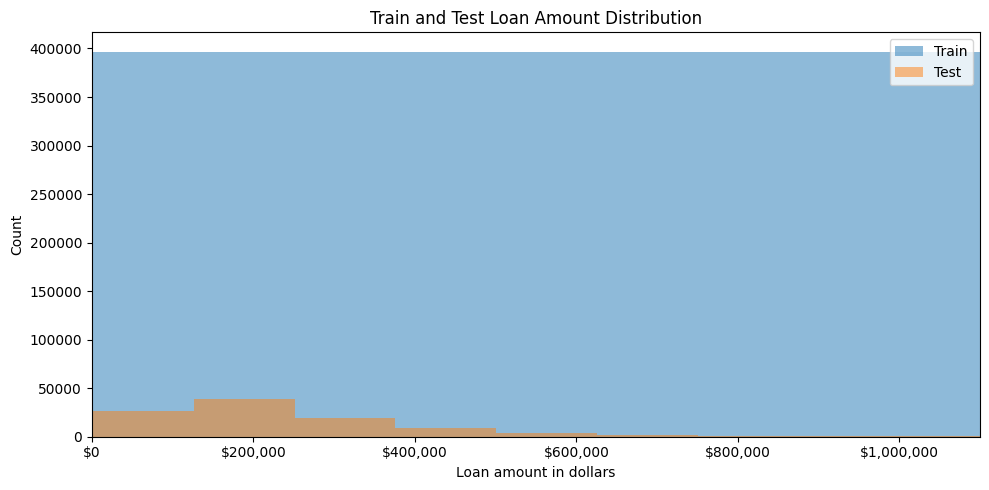

In [40]:
split_check = pd.DataFrame({
    "set": ["train", "test"],
    "rows": [len(train_df_base), len(test_df_base)],
    "target_mean": [y_train_raw.mean(), y_test_raw.mean()],
    "target_median": [y_train_raw.median(), y_test_raw.median()],
    "target_q95": [y_train_raw.quantile(0.95), y_test_raw.quantile(0.95)],
    "target_q99": [y_train_raw.quantile(0.99), y_test_raw.quantile(0.99)]
})

display(split_check)

plt.figure(figsize=(10, 5))
plt.hist(y_train_raw * 1000, bins=80, alpha=0.5, label="Train")
plt.hist(y_test_raw * 1000, bins=80, alpha=0.5, label="Test")
plt.xlim(0, (target_values * 1000).quantile(0.99))
plt.title("Train and Test Loan Amount Distribution")
plt.xlabel("Loan amount in dollars")
plt.ylabel("Count")
plt.legend()
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# Export two full regression datasets
# 1. With sensitive features
# 2. Without sensitive features
#
# No train-test split is saved.
# Splitting will be performed later inside the modeling notebook.
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Required notebook objects
# ------------------------------------------------------------
required_objects = [
    "df_fe",
    "candidate_model_features",
    "main_model_features",
    "TARGET_COL"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        f"These required objects were not found: {missing_objects}"
    )


# ------------------------------------------------------------
# Prepare feature lists
# ------------------------------------------------------------

# All selected features, including sensitive features
features_with_sensitive = list(
    dict.fromkeys(candidate_model_features)
)

# Selected features after removing sensitive features
features_without_sensitive = list(
    dict.fromkeys(main_model_features)
)


# Prevent target duplication if it exists in a feature list
features_with_sensitive = [
    column
    for column in features_with_sensitive
    if column != TARGET_COL
]

features_without_sensitive = [
    column
    for column in features_without_sensitive
    if column != TARGET_COL
]


# ------------------------------------------------------------
# Validate required columns
# ------------------------------------------------------------
all_required_columns = list(
    dict.fromkeys(
        [TARGET_COL]
        + features_with_sensitive
        + features_without_sensitive
    )
)

missing_columns = [
    column
    for column in all_required_columns
    if column not in df_fe.columns
]

if missing_columns:
    raise KeyError(
        "These columns were not found in df_fe:\n"
        f"{missing_columns}"
    )


# ------------------------------------------------------------
# Create dataset with sensitive features
# ------------------------------------------------------------
regression_with_sensitive_df = df_fe[
    [TARGET_COL] + features_with_sensitive
].copy()


# ------------------------------------------------------------
# Create dataset without sensitive features
# ------------------------------------------------------------
regression_without_sensitive_df = df_fe[
    [TARGET_COL] + features_without_sensitive
].copy()


# ------------------------------------------------------------
# Reset index
# The old DataFrame index should not become a model feature
# ------------------------------------------------------------
regression_with_sensitive_df = (
    regression_with_sensitive_df
    .reset_index(drop=True)
)

regression_without_sensitive_df = (
    regression_without_sensitive_df
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Validate target
# ------------------------------------------------------------
for dataset_name, dataset in {
    "with sensitive features": regression_with_sensitive_df,
    "without sensitive features": regression_without_sensitive_df
}.items():

    if dataset[TARGET_COL].isna().any():
        missing_target_count = int(
            dataset[TARGET_COL].isna().sum()
        )

        raise ValueError(
            f"{dataset_name} contains "
            f"{missing_target_count:,} missing target values."
        )

    if not pd.api.types.is_numeric_dtype(
        dataset[TARGET_COL]
    ):
        raise TypeError(
            f"The target column in {dataset_name} "
            "must be numeric."
        )


# ------------------------------------------------------------
# Check infinite numeric values
# ------------------------------------------------------------
for dataset_name, dataset in {
    "with sensitive features": regression_with_sensitive_df,
    "without sensitive features": regression_without_sensitive_df
}.items():

    numeric_columns = dataset.select_dtypes(
        include=np.number
    ).columns

    numeric_values = dataset[
        numeric_columns
    ].to_numpy(dtype="float64")

    infinite_count = int(
        np.isinf(numeric_values).sum()
    )

    if infinite_count > 0:
        raise ValueError(
            f"{dataset_name} contains "
            f"{infinite_count:,} infinite values."
        )


# ------------------------------------------------------------
# Confirm that both datasets contain the same observations
# ------------------------------------------------------------
if len(regression_with_sensitive_df) != len(
    regression_without_sensitive_df
):
    raise ValueError(
        "The two datasets have different row counts."
    )


if not regression_with_sensitive_df[
    TARGET_COL
].equals(
    regression_without_sensitive_df[TARGET_COL]
):
    raise ValueError(
        "The target values or row order differ "
        "between the two datasets."
    )


# ------------------------------------------------------------
# Create output directory
# ------------------------------------------------------------
output_directory = Path("data/processed")

output_directory.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# File paths
# ------------------------------------------------------------
with_sensitive_path = (
    output_directory
    / "regression_with_sensitive_features.csv"
)

without_sensitive_path = (
    output_directory
    / "regression_without_sensitive_features.csv"
)


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------
regression_with_sensitive_df.to_csv(
    with_sensitive_path,
    index=False,
    encoding="utf-8-sig"
)

regression_without_sensitive_df.to_csv(
    without_sensitive_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# Final report
# ------------------------------------------------------------
print("=" * 70)
print("REGRESSION DATASETS EXPORTED")
print("=" * 70)

print("\nDataset with sensitive features")
print(
    "Shape:",
    regression_with_sensitive_df.shape
)
print(
    "Number of input features:",
    len(features_with_sensitive)
)
print(
    "Saved to:",
    with_sensitive_path
)

print("\nDataset without sensitive features")
print(
    "Shape:",
    regression_without_sensitive_df.shape
)
print(
    "Number of input features:",
    len(features_without_sensitive)
)
print(
    "Saved to:",
    without_sensitive_path
)

print("\nTarget column:", TARGET_COL)

print(
    "Sensitive features removed:",
    sorted(
        set(features_with_sensitive)
        - set(features_without_sensitive)
    )
)

print("=" * 70)

display(
    regression_with_sensitive_df.head()
)

display(
    regression_without_sensitive_df.head()
)

REGRESSION DATASETS EXPORTED

Dataset with sensitive features
Shape: (499736, 44)
Number of input features: 43
Saved to: data\processed\regression_with_sensitive_features.csv

Dataset without sensitive features
Shape: (499736, 36)
Number of input features: 35
Saved to: data\processed\regression_without_sensitive_features.csv

Target column: loan_amount_000s
Sensitive features removed: ['applicant_ethnicity_name', 'applicant_race_name_1', 'applicant_sex_name', 'co_applicant_ethnicity_name', 'co_applicant_race_name_1', 'co_applicant_sex_name', 'majority_minority_tract', 'minority_population']


,loan_amount_000s,respondent_id,agency_name,loan_type_name,property_type_name,loan_purpose_name,owner_occupancy_name,preapproval_name,msamd_name,state_name,state_code,county_name,county_code,census_tract_number,applicant_ethnicity_name,co_applicant_ethnicity_name,applicant_race_name_1,co_applicant_race_name_1,applicant_sex_name,co_applicant_sex_name,applicant_income_000s,lien_status_name,population,minority_population,hud_median_family_income,tract_to_msamd_income,number_of_owner_occupied_units,number_of_1_to_4_family_units,log1p_applicant_income,log1p_population,log1p_hud_median_family_income,log1p_owner_occupied_units,log1p_1_to_4_family_units,applicant_income_to_area_income,tract_income_ratio,owner_occupied_unit_ratio,family_units_per_1000_people,owner_occupied_units_per_1000_people,has_co_applicant,loan_program_group,applicant_income_area_group,tract_income_level,majority_minority_tract,us_region
0,603,0000035295,Federal Deposit Insurance Corporation,Conventional,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,Not applicable,"Greenville, Anderson, Mauldin - SC",South Carolina,45,Greenville County,45,28.13,Not Hispanic or Latino,Not Hispanic or Latino,White,White,Male,Female,529,Secured by a first lien,4444,18.360001,57800,268.309998,1359,1457,6.272877,8.399535,10.964761,7.215240,7.284821,9.152249,2.6831,0.932739,327.857786,305.805581,1,Conventional,High,High,Not majority minority,South
1,341,33-0941669,Department of Housing and Urban Development,FHA-insured,One-to-four family dwelling (other than manufa...,Refinancing,Owner-occupied as a principal dwelling,Not applicable,"San Diego, Carlsbad - CA",California,6,San Diego County,73,85.04,"Information not provided by applicant in mail,...","Information not provided by applicant in mail,...",White,White,Male,Female,71,Secured by a first lien,5901,31.440001,79300,109.379997,1551,2276,4.276666,8.683047,11.281006,7.347300,7.730614,0.895334,1.0938,0.681459,385.697339,262.836807,1,Government backed,Moderate,Moderate,Not majority minority,West
2,215,7505400005,Department of Housing and Urban Development,VA-guaranteed,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,Not applicable,"Hanford, Corcoran - CA",California,6,Kings County,31,11.00,"Information not provided by applicant in mail,...",No co-applicant,"Information not provided by applicant in mail,...",No co-applicant,"Information not provided by applicant in mail,...",No co-applicant,59,Secured by a first lien,6792,87.510002,50200,62.900002,716,1786,4.094345,8.823648,10.823790,6.575076,7.488294,1.175299,0.6290,0.400896,262.956419,105.418139,0,Government backed,Moderate,Low,Majority minority,West
3,968,0000761806,Consumer Financial Protection Bureau,Conventional,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,Preapproval was not requested,"Hartford, West Hartford, East Hartford - CT",Connecticut,9,Hartford County,3,4602.02,"Information not provided by applicant in mail,...",No co-applicant,"Information not provided by applicant in mail,...",No co-applicant,"Information not provided by applicant in mail,...",No co-applicant,350,Secured by a first lien,4277,15.920000,90200,162.750000,1147,1549,5.860786,8.361241,11.409796,7.045777,7.346010,3.880266,1.6275,0.740478,362.169745,268.178630,0,Conventional,High,High,Not majority minority,Northeast
4,115,0002735146,Consumer Financial Protection Bureau,Conventional,One-to-four family dwelling (other than manufa...,Refinancing,Owner-occupied as a principal dwelling,Not applicable,"Daphne, Fairhope, Foley - AL",Alabama,1,Baldwin County,3,107.04,Not Hispanic or Latino,Not Hispanic or Latino,White,White,Female,Male,46,Secured by a first lien,5411,20.240000,61500,111.500000,1338,2036,3.850148,8.596374,11.026809,7.199678,7.619233,0.747967,1.1150,0.657171,376.270560,247.274071,1,Conventional,Low,Moderate,Not majority minority,South


,loan_amount_000s,respondent_id,agency_name,loan_type_name,property_type_name,loan_purpose_name,owner_occupancy_name,preapproval_name,msamd_name,state_name,state_code,county_name,county_code,census_tract_number,applicant_income_000s,lien_status_name,population,hud_median_family_income,tract_to_msamd_income,number_of_owner_occupied_units,number_of_1_to_4_family_units,log1p_applicant_income,log1p_population,log1p_hud_median_family_income,log1p_owner_occupied_units,log1p_1_to_4_family_units,applicant_income_to_area_income,tract_income_ratio,owner_occupied_unit_ratio,family_units_per_1000_people,owner_occupied_units_per_1000_people,has_co_applicant,loan_program_group,applicant_income_area_group,tract_income_level,us_region
0,603,0000035295,Federal Deposit Insurance Corporation,Conventional,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,Not applicable,"Greenville, Anderson, Mauldin - SC",South Carolina,45,Greenville County,45,28.13,529,Secured by a first lien,4444,57800,268.309998,1359,1457,6.272877,8.399535,10.964761,7.215240,7.284821,9.152249,2.6831,0.932739,327.857786,305.805581,1,Conventional,High,High,South
1,341,33-0941669,Department of Housing and Urban Development,FHA-insured,One-to-four family dwelling (other than manufa...,Refinancing,Owner-occupied as a principal dwelling,Not applicable,"San Diego, Carlsbad - CA",California,6,San Diego County,73,85.04,71,Secured by a first lien,5901,79300,109.379997,1551,2276,4.276666,8.683047,11.281006,7.347300,7.730614,0.895334,1.0938,0.681459,385.697339,262.836807,1,Government backed,Moderate,Moderate,West
2,215,7505400005,Department of Housing and Urban Development,VA-guaranteed,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,Not applicable,"Hanford, Corcoran - CA",California,6,Kings County,31,11.00,59,Secured by a first lien,6792,50200,62.900002,716,1786,4.094345,8.823648,10.823790,6.575076,7.488294,1.175299,0.6290,0.400896,262.956419,105.418139,0,Government backed,Moderate,Low,West
3,968,0000761806,Consumer Financial Protection Bureau,Conventional,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,Preapproval was not requested,"Hartford, West Hartford, East Hartford - CT",Connecticut,9,Hartford County,3,4602.02,350,Secured by a first lien,4277,90200,162.750000,1147,1549,5.860786,8.361241,11.409796,7.045777,7.346010,3.880266,1.6275,0.740478,362.169745,268.178630,0,Conventional,High,High,Northeast
4,115,0002735146,Consumer Financial Protection Bureau,Conventional,One-to-four family dwelling (other than manufa...,Refinancing,Owner-occupied as a principal dwelling,Not applicable,"Daphne, Fairhope, Foley - AL",Alabama,1,Baldwin County,3,107.04,46,Secured by a first lien,5411,61500,111.500000,1338,2036,3.850148,8.596374,11.026809,7.199678,7.619233,0.747967,1.1150,0.657171,376.270560,247.274071,1,Conventional,Low,Moderate,South
